In [1]:

# Meta-Analysis of Sedation and Extubation Outcomes
# Random-effects meta-analysis using DerSimonian-Laird method

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path
import glob
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import numpy as np

# Change to project root directory
os.chdir('..')
print(f"Working directory: {os.getcwd()}")

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')


Working directory: /Users/wliao0504/.cursor/worktrees/CLIF-epi-of-sedation/xYjxu


# Config

In [2]:
# Configuration
BOX_ROOT = Path("/Users/wliao0504/Library/CloudStorage/Box-Box/CLIF/projects/CLIF-epi-of-sedation")
OUTPUT_DIR = Path("output/pooled")
CURRENT_TIME_STR = datetime.now().strftime('%Y%m%d_%H%M%S')

# Create output directory if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Sites to exclude from analysis (case-sensitive)
SITES_TO_SKIP = ['OHSU', 'Michigan']  # Add site names to skip (e.g., ['OHSU', 'SITE2'])

# Variables of interest
SEDATION_VARS = ['propofol_diff', 'fentanyl_eq_diff', 'midazolam_eq_diff']

# Outcome variable selection: 'sbt_done', 'success_extub', or 'both'
OUTCOME_TYPE = 'both'  # Change to 'sbt_done', 'success_extub', or 'both'

# Map outcome types to their corresponding file patterns and model types
OUTCOME_CONFIG = {
    'sbt_done': {
        'file_pattern': 'gee',
        'outcome_var': 'sbt_done_next_day',
        'description': 'SBT Done Next Day (GEE Model)',
        'interpretation': 'SBT completion'
    },
    'success_extub': {
        'file_pattern': 'logit',
        'outcome_var': 'success_extub_next_day',
        'description': 'Successful Extubation Next Day (Logit Model)',
        'interpretation': 'successful extubation'
    }
}

print(f"BOX_ROOT: {BOX_ROOT}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"Timestamp: {CURRENT_TIME_STR}")
print(f"Outcome type(s) to analyze: {OUTCOME_TYPE}")
if SITES_TO_SKIP:
    print(f"Sites to skip: {', '.join(SITES_TO_SKIP)}")
else:
    print(f"Sites to skip: None")


BOX_ROOT: /Users/wliao0504/Library/CloudStorage/Box-Box/CLIF/projects/CLIF-epi-of-sedation
OUTPUT_DIR: output/pooled
Timestamp: 20251105_142350
Outcome type(s) to analyze: both
Sites to skip: OHSU, Michigan


# Utils

In [3]:
# Utility Functions for Random-Effects Meta-Analysis (DerSimonian-Laird)

def interpret_odds_ratio(variable_name, or_value, ci_lower, ci_upper, p_value, outcome_desc, is_pooled=False):
    """
    Generate plain language interpretation of an odds ratio.
    
    Parameters:
    -----------
    variable_name : str
        Name of the variable
    or_value : float
        Odds ratio
    ci_lower : float
        Lower bound of 95% CI
    ci_upper : float
        Upper bound of 95% CI
    p_value : float
        P-value
    outcome_desc : str
        Description of outcome (e.g., 'SBT completion', 'successful extubation')
    is_pooled : bool
        Whether this is a pooled estimate
        
    Returns:
    --------
    str : Plain language interpretation
    """
    # Determine direction and magnitude
    if or_value > 1:
        direction = "increase"
        pct_change = (or_value - 1) * 100
    else:
        direction = "decrease"
        pct_change = (1 - or_value) * 100
    
    # Determine significance
    is_significant = p_value < 0.05
    ci_excludes_one = not (ci_lower <= 1 <= ci_upper)
    
    # Build interpretation
    estimate_type = "Pooled estimate" if is_pooled else "Estimate"
    
    interpretation = f"{estimate_type} for {variable_name}:\n"
    interpretation += f"  OR = {or_value:.3f} (95% CI: {ci_lower:.3f}-{ci_upper:.3f}, p = {p_value:.4f})\n"
    
    if is_significant and ci_excludes_one:
        interpretation += f"  → A 1-unit increase in {variable_name} is associated with a "
        interpretation += f"{pct_change:.1f}% {direction} in the odds of {outcome_desc} next day.\n"
        interpretation += f"  → This association is STATISTICALLY SIGNIFICANT (p < 0.05, CI excludes 1).\n"
    else:
        interpretation += f"  → A 1-unit increase in {variable_name} is associated with a "
        interpretation += f"{pct_change:.1f}% {direction} in the odds of {outcome_desc} next day.\n"
        interpretation += f"  → This association is NOT statistically significant (p ≥ 0.05 or CI includes 1).\n"
    
    # Clinical interpretation based on variable and outcome
    if 'propofol' in variable_name.lower():
        interpretation += f"  → Clinical note: Higher night-day propofol dose differences "
        interpretation += f"{'may indicate' if is_significant else 'do not significantly affect'} readiness for {outcome_desc}.\n"
    elif 'fentanyl' in variable_name.lower():
        interpretation += f"  → Clinical note: Opioid dose variations between shifts "
        interpretation += f"{'may influence' if is_significant else 'do not significantly affect'} {outcome_desc} outcomes.\n"
    elif 'midazolam' in variable_name.lower():
        interpretation += f"  → Clinical note: Benzodiazepine equivalent variations "
        interpretation += f"{'may be relevant to' if is_significant else 'show no clear association with'} {outcome_desc}.\n"
    
    return interpretation


def random_effects_meta_analysis(effects, variances, study_names=None):
    """
    Perform random-effects meta-analysis using DerSimonian-Laird method.
    
    Parameters:
    -----------
    effects : array-like
        Effect estimates (e.g., log odds ratios) from each study
    variances : array-like
        Variances of the effect estimates
    study_names : list, optional
        Names of the studies
        
    Returns:
    --------
    dict with keys:
        - pooled_effect: Pooled effect estimate
        - pooled_se: Standard error of pooled effect
        - pooled_ci_lower: Lower 95% CI
        - pooled_ci_upper: Upper 95% CI
        - tau2: Between-study variance
        - Q: Q-statistic for heterogeneity
        - Q_pval: P-value for Q-statistic
        - I2: I-squared statistic (percentage)
        - studies: DataFrame with individual study results
    """
    effects = np.array(effects)
    variances = np.array(variances)
    n_studies = len(effects)
    
    if study_names is None:
        study_names = [f"Study {i+1}" for i in range(n_studies)]
    
    # Calculate weights for fixed-effect model
    weights_fe = 1 / variances
    
    # Calculate Q-statistic
    pooled_effect_fe = np.sum(weights_fe * effects) / np.sum(weights_fe)
    Q = np.sum(weights_fe * (effects - pooled_effect_fe)**2)
    df = n_studies - 1
    Q_pval = 1 - stats.chi2.cdf(Q, df) if df > 0 else np.nan
    
    # Calculate tau-squared (between-study variance) using DerSimonian-Laird
    C = np.sum(weights_fe) - np.sum(weights_fe**2) / np.sum(weights_fe)
    tau2 = max(0, (Q - df) / C) if C > 0 else 0
    
    # Calculate I-squared
    I2 = max(0, (Q - df) / Q * 100) if Q > 0 else 0
    
    # Calculate random-effects weights
    weights_re = 1 / (variances + tau2)
    
    # Calculate pooled effect and SE
    pooled_effect = np.sum(weights_re * effects) / np.sum(weights_re)
    pooled_var = 1 / np.sum(weights_re)
    pooled_se = np.sqrt(pooled_var)
    
    # Calculate 95% CI
    pooled_ci_lower = pooled_effect - 1.96 * pooled_se
    pooled_ci_upper = pooled_effect + 1.96 * pooled_se
    
    # Create study results DataFrame
    studies_df = pd.DataFrame({
        'study': study_names,
        'effect': effects,
        'se': np.sqrt(variances),
        'variance': variances,
        'weight': weights_re / np.sum(weights_re) * 100  # as percentage
    })
    
    return {
        'pooled_effect': pooled_effect,
        'pooled_se': pooled_se,
        'pooled_ci_lower': pooled_ci_lower,
        'pooled_ci_upper': pooled_ci_upper,
        'tau2': tau2,
        'Q': Q,
        'Q_pval': Q_pval,
        'I2': I2,
        'studies': studies_df
    }


def create_forest_plot(meta_results, variable_name, output_path=None):
    """
    Create a forest plot for meta-analysis results.
    
    Parameters:
    -----------
    meta_results : dict
        Results from random_effects_meta_analysis()
    variable_name : str
        Name of the variable being analyzed
    output_path : str or Path, optional
        Path to save the figure
    """
    studies_df = meta_results['studies']
    
    # Convert log OR to OR for plotting
    studies_df['or'] = np.exp(studies_df['effect'])
    studies_df['or_ci_lower'] = np.exp(studies_df['effect'] - 1.96 * studies_df['se'])
    studies_df['or_ci_upper'] = np.exp(studies_df['effect'] + 1.96 * studies_df['se'])
    
    pooled_or = np.exp(meta_results['pooled_effect'])
    pooled_or_lower = np.exp(meta_results['pooled_ci_lower'])
    pooled_or_upper = np.exp(meta_results['pooled_ci_upper'])
    
    n_studies = len(studies_df)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, max(6, n_studies * 0.5 + 2)))
    
    # Plot individual studies
    y_positions = range(n_studies, 0, -1)
    for i, (idx, row) in enumerate(studies_df.iterrows()):
        y = y_positions[i]
        
        # Plot CI line
        ax.plot([row['or_ci_lower'], row['or_ci_upper']], [y, y], 
                'k-', linewidth=1.5, zorder=1)
        
        # Plot point estimate (square sized by weight)
        size = row['weight'] * 10  # Scale for visibility
        ax.scatter(row['or'], y, s=size, marker='s', 
                  color='steelblue', edgecolors='black', linewidths=1, zorder=2)
    
    # Plot pooled estimate (diamond)
    pooled_y = 0
    diamond_height = 0.3
    diamond_x = [pooled_or_lower, pooled_or, pooled_or_upper, pooled_or]
    diamond_y = [pooled_y, pooled_y + diamond_height, pooled_y, pooled_y - diamond_height]
    ax.fill(diamond_x, diamond_y, color='darkred', alpha=0.7, edgecolor='black', linewidth=2, zorder=3)
    
    # Add vertical line at OR = 1
    ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # Set y-axis labels
    y_labels = list(studies_df['study']) + ['Pooled']
    ax.set_yticks(list(y_positions) + [pooled_y])
    ax.set_yticklabels(y_labels)
    
    # Set x-axis to log scale
    ax.set_xscale('log')
    ax.set_xlabel('Odds Ratio (95% CI)', fontsize=12, fontweight='bold')
    
    # Title with heterogeneity statistics
    title = f'Forest Plot: {variable_name}\n'
    title += f'I² = {meta_results["I2"]:.1f}%, τ² = {meta_results["tau2"]:.4f}, '
    title += f'Q = {meta_results["Q"]:.2f} (p = {meta_results["Q_pval"]:.3f})'
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Add grid
    ax.grid(True, axis='x', alpha=0.3, linestyle='-', linewidth=0.5)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save if path provided
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Forest plot saved to: {output_path}")
    
    return fig, ax

print("Meta-analysis utility functions loaded successfully.")


Meta-analysis utility functions loaded successfully.


# 1. Data Loading and Preparation


In [4]:
# Auto-discover site-specific outcome summary files
def find_latest_outcome_files(box_root, outcome_type='sbt_done'):
    """
    Find the most recent outcome summary files for each site.
    
    Parameters:
    -----------
    box_root : Path
        Root directory for Box files
    outcome_type : str
        Type of outcome: 'sbt_done' or 'success_extub'
        
    Returns:
    --------
    dict : Dictionary mapping site names to file paths
    """
    # Get the file pattern for this outcome type
    file_pattern = OUTCOME_CONFIG[outcome_type]['file_pattern']
    pattern = str(box_root / f"*/final/*_{file_pattern}_summary_*.csv")
    summary_files = glob.glob(pattern)
    
    if not summary_files:
        outcome_desc = OUTCOME_CONFIG[outcome_type]['description']
        print(f"Warning: No files found for {outcome_desc} matching pattern: {pattern}")
        return {}
    
    # Group files by site
    site_files = {}
    for filepath in summary_files:
        path_obj = Path(filepath)
        site_name = path_obj.parts[-3]  # Get site name from directory structure
        
        # Skip sites in SITES_TO_SKIP list
        if site_name in SITES_TO_SKIP:
            continue
        
        # Extract timestamp from filename
        filename = path_obj.name
        # Pattern: {site}_{file_pattern}_summary_{timestamp}.csv
        parts = filename.replace('.csv', '').split('_')
        if len(parts) >= 4:
            timestamp = parts[-1]  # Last part is timestamp
            
            if site_name not in site_files:
                site_files[site_name] = []
            site_files[site_name].append((timestamp, filepath))
    
    # Get the most recent file for each site
    latest_files = {}
    for site_name, files in site_files.items():
        # Sort by timestamp (descending) and get the most recent
        files.sort(reverse=True, key=lambda x: x[0])
        latest_files[site_name] = files[0][1]
    
    return latest_files

# Determine which outcome types to analyze
outcome_types_to_analyze = []
if OUTCOME_TYPE == 'both':
    outcome_types_to_analyze = ['sbt_done', 'success_extub']
else:
    outcome_types_to_analyze = [OUTCOME_TYPE]

# Find all available site files for each outcome type
all_outcome_files = {}
for outcome_type in outcome_types_to_analyze:
    site_files = find_latest_outcome_files(BOX_ROOT, outcome_type)
    if site_files:
        all_outcome_files[outcome_type] = site_files
        outcome_desc = OUTCOME_CONFIG[outcome_type]['description']
        print(f"\nFound {len(site_files)} site(s) with {outcome_desc} results:")
        for site, filepath in site_files.items():
            print(f"  - {site}: {Path(filepath).name}")
    else:
        outcome_desc = OUTCOME_CONFIG[outcome_type]['description']
        print(f"\nNo {outcome_desc} results found.")

if not all_outcome_files:
    raise ValueError("No site files found for any outcome type. Please check the BOX_ROOT path and file patterns.")



Found 6 site(s) with SBT Done Next Day (GEE Model) results:
  - RUSH: rush_gee_summary_20251105_110219.csv
  - UCMC: ucmc_gee_summary_20251104_164214.csv
  - MIMIC: mimic_gee_summary_20251104_164105.csv
  - UMN: umn_gee_summary_20251105_051838.csv
  - NW: nu_gee_summary_20251104_171900.csv
  - Emory: emory_gee_summary_20251104_183253.csv

Found 6 site(s) with Successful Extubation Next Day (Logit Model) results:
  - RUSH: rush_logit_summary_20251105_110219.csv
  - UCMC: ucmc_logit_summary_20251104_164214.csv
  - MIMIC: mimic_logit_summary_20251104_164105.csv
  - UMN: umn_logit_summary_20251105_051838.csv
  - NW: nu_logit_summary_20251104_171900.csv
  - Emory: emory_logit_summary_20251104_183253.csv


In [5]:
# Load data from all sites and extract sedation variable coefficients
def load_site_results(file_path, site_name, variables_of_interest, outcome_type='sbt_done'):
    """
    Load outcome summary results for a specific site.
    
    Parameters:
    -----------
    file_path : str
        Path to the summary CSV file
    site_name : str
        Name of the site
    variables_of_interest : list
        List of variable names to extract
    outcome_type : str
        Type of outcome ('sbt_done' or 'success_extub')
        
    Returns:
    --------
    DataFrame with columns: site, variable, coef, se, pval, outcome_type
    """
    # Read the CSV file
    df = pd.read_csv(file_path)
    
    # The summary table typically has columns like:
    # Column 0: variable name, Column 1: coef, Column 2: std err, Column 3: z, Column 4: P>|z|, Column 5-6: CI
    # But column names may vary, so we'll be flexible
    
    # Try to identify the correct columns
    col_names = df.columns.tolist()
    
    # Common column name patterns
    if len(col_names) >= 3:
        var_col = col_names[0]  # First column is usually the variable name
        coef_col = col_names[1]  # Second column is usually coefficient
        se_col = col_names[2]    # Third column is usually standard error
        
        # Look for p-value column
        pval_col = None
        for col in col_names:
            if 'P>' in col or 'p-value' in col.lower() or 'pval' in col.lower():
                pval_col = col
                break
        if pval_col is None and len(col_names) >= 5:
            pval_col = col_names[4]  # Often 5th column
    else:
        raise ValueError(f"Unexpected file format in {file_path}")
    
    # Filter for variables of interest
    results = []
    for var in variables_of_interest:
        var_data = df[df[var_col] == var]
        if len(var_data) > 0:
            row = var_data.iloc[0]
            results.append({
                'site': site_name,
                'variable': var,
                'coef': float(row[coef_col]),
                'se': float(row[se_col]),
                'pval': float(row[pval_col]) if pval_col else np.nan,
                'outcome_type': outcome_type
            })
        else:
            outcome_desc = OUTCOME_CONFIG[outcome_type]['description']
            print(f"Warning: Variable '{var}' not found in {site_name} {outcome_desc} results")
    
    return pd.DataFrame(results)

# Load all site results for each outcome type
all_combined_data = {}

for outcome_type, site_files in all_outcome_files.items():
    outcome_desc = OUTCOME_CONFIG[outcome_type]['description']
    print(f"\n{'='*70}")
    print(f"Loading {outcome_desc}")
    print(f"{'='*70}")
    
    all_site_data = []
    for site_name, file_path in site_files.items():
        try:
            site_data = load_site_results(file_path, site_name, SEDATION_VARS, outcome_type)
            all_site_data.append(site_data)
            print(f"✓ Loaded {len(site_data)} variables from {site_name}")
        except Exception as e:
            print(f"✗ Error loading {site_name}: {str(e)}")
    
    if all_site_data:
        # Combine all site data for this outcome type
        combined_data = pd.concat(all_site_data, ignore_index=True)
        
        # Calculate variance from SE
        combined_data['variance'] = combined_data['se'] ** 2
        
        all_combined_data[outcome_type] = combined_data
        
        print(f"\n{len(combined_data)} total observations loaded for {outcome_desc}")
        print("\nData summary:")
        print(combined_data.to_string(index=False))

# Rename site NW to NU (typo correction) across all outcome data
for outcome_type in all_combined_data.keys():
    all_combined_data[outcome_type]['site'] = all_combined_data[outcome_type]['site'].replace({'NW': 'NU'})
    
print("\n✓ Site name correction applied: NW → NU")



Loading SBT Done Next Day (GEE Model)
✓ Loaded 3 variables from RUSH
✓ Loaded 3 variables from UCMC
✓ Loaded 3 variables from MIMIC
✓ Loaded 3 variables from UMN
✓ Loaded 3 variables from NW
✓ Loaded 3 variables from Emory

18 total observations loaded for SBT Done Next Day (GEE Model)

Data summary:
 site          variable    coef       se  pval outcome_type     variance
 RUSH     propofol_diff -0.0002 0.000044 0.000     sbt_done 1.927210e-09
 RUSH  fentanyl_eq_diff -0.0003 0.000041 0.000     sbt_done 1.689210e-09
 RUSH midazolam_eq_diff -0.0019 0.001000 0.024     sbt_done 1.000000e-06
 UCMC     propofol_diff -0.0001 0.000025 0.000     sbt_done 6.051600e-10
 UCMC  fentanyl_eq_diff -0.0003 0.000040 0.000     sbt_done 1.568160e-09
 UCMC midazolam_eq_diff -0.0084 0.003000 0.003     sbt_done 9.000000e-06
MIMIC     propofol_diff -0.0001 0.000017 0.000     sbt_done 2.822400e-10
MIMIC  fentanyl_eq_diff -0.0004 0.000031 0.000     sbt_done 9.363600e-10
MIMIC midazolam_eq_diff -0.0102 0.002000

## Understanding the Two Outcome Variables

This analysis examines **two distinct outcomes** related to mechanical ventilation and sedation:

### 1. SBT Done Next Day (GEE Model)
- **Outcome Variable**: `sbt_done_next_day`
- **Definition**: Whether a Spontaneous Breathing Trial (SBT) is completed the following day
- **Model Type**: GEE (Generalized Estimating Equations)
- **Why GEE**: Population-averaged effects; accounts for within-patient correlation across multiple days
- **Interpretation**: Marginal (population-level) odds ratios
- **Clinical Question**: Does sedation practice affect readiness for breathing trials?

### 2. Successful Extubation Next Day (Logit Model)
- **Outcome Variable**: `success_extub_next_day`
- **Definition**: Whether extubation is successful without reintubation the following day
- **Model Type**: Logistic regression with clustered standard errors
- **Why Logit**: Subject-specific effects with robust SEs accounting for clustering
- **Interpretation**: Conditional (subject-specific) odds ratios
- **Clinical Question**: Does sedation practice affect likelihood of successful extubation?

### Key Points
- **Different outcomes**: These are separate analyses answering different clinical questions
- **Same predictors**: Both examine sedation dose differences (night-day) plus covariates
- **Complementary insights**: SBT readiness vs. actual extubation success
- **Not comparable**: Results should not be directly compared as they predict different outcomes

### Model Specifications
Both models include:
- **Predictors**: `propofol_diff`, `fentanyl_eq_diff`, `midazolam_eq_diff` (night-day differences)
- **Baseline sedation**: Day and night doses separately
- **Covariates**: pH levels, P/F ratio, vasopressor support (norepinephrine equivalents), age
- **Clustering**: By `hospitalization_id` to account for repeated daily observations

---

# 2. Perform Random-Effects Meta-Analysis


In [6]:
# Perform meta-analysis for each outcome type and sedation variable
all_meta_results = {}

for outcome_type, combined_data in all_combined_data.items():
    outcome_desc = OUTCOME_CONFIG[outcome_type]['description']
    outcome_interp = OUTCOME_CONFIG[outcome_type]['interpretation']
    print(f"\n{'#'*70}")
    print(f"### META-ANALYSIS FOR {outcome_desc.upper()} ###")
    print(f"{'#'*70}")
    
    meta_results = {}
    
    for var in SEDATION_VARS:
        print(f"\n{'='*70}")
        print(f"Meta-Analysis for: {var}")
        print(f"{'='*70}")
        
        # Filter data for this variable
        var_data = combined_data[combined_data['variable'] == var].copy()
        
        if len(var_data) < 2:
            print(f"Warning: Less than 2 sites have data for {var}. Skipping meta-analysis.")
            continue
        
        # Extract effects and variances
        effects = var_data['coef'].values
        variances = var_data['variance'].values
        study_names = var_data['site'].values
        pvals = var_data['pval'].values
        
        # Perform random-effects meta-analysis
        results = random_effects_meta_analysis(effects, variances, study_names)
        
        # Store results
        meta_results[var] = results
        
        # Display results
        print(f"\nIndividual Study Results:")
        print(results['studies'].to_string(index=False))
        
        print(f"\n{'─'*70}")
        print(f"Pooled Results (Log Odds Ratio):")
        print(f"  Estimate: {results['pooled_effect']:.4f}")
        print(f"  Standard Error: {results['pooled_se']:.4f}")
        print(f"  95% CI: [{results['pooled_ci_lower']:.4f}, {results['pooled_ci_upper']:.4f}]")
        
        print(f"\nPooled Results (Odds Ratio):")
        pooled_or = np.exp(results['pooled_effect'])
        pooled_or_lower = np.exp(results['pooled_ci_lower'])
        pooled_or_upper = np.exp(results['pooled_ci_upper'])
        # Calculate pooled p-value using z-test
        pooled_z = results['pooled_effect'] / results['pooled_se']
        pooled_pval = 2 * (1 - stats.norm.cdf(abs(pooled_z)))
        print(f"  Odds Ratio: {pooled_or:.4f}")
        print(f"  95% CI: [{pooled_or_lower:.4f}, {pooled_or_upper:.4f}]")
        print(f"  P-value: {pooled_pval:.4f}")
        
        print(f"\nHeterogeneity Statistics:")
        print(f"  Q-statistic: {results['Q']:.2f} (p = {results['Q_pval']:.4f})")
        print(f"  I²: {results['I2']:.1f}%")
        print(f"  τ² (tau-squared): {results['tau2']:.4f}")
        
        # Interpretation
        if results['Q_pval'] < 0.05:
            print(f"  → Significant heterogeneity detected (p < 0.05)")
        else:
            print(f"  → No significant heterogeneity detected (p ≥ 0.05)")
        
        if results['I2'] < 25:
            print(f"  → Low heterogeneity (I² < 25%)")
        elif results['I2'] < 50:
            print(f"  → Moderate heterogeneity (25% ≤ I² < 50%)")
        elif results['I2'] < 75:
            print(f"  → Substantial heterogeneity (50% ≤ I² < 75%)")
        else:
            print(f"  → Considerable heterogeneity (I² ≥ 75%)")
        
        # Plain language interpretation
        print(f"\n{'─'*70}")
        print("PLAIN LANGUAGE INTERPRETATION:")
        print(f"{'─'*70}")
        interpretation = interpret_odds_ratio(var, pooled_or, pooled_or_lower, pooled_or_upper, pooled_pval, outcome_interp, is_pooled=True)
        print(interpretation)
    
    # Store results for this outcome type
    all_meta_results[outcome_type] = meta_results
    
    print(f"\n{'='*70}")
    print(f"Meta-analysis completed for {outcome_desc}: {len(meta_results)} variable(s)")
    print(f"{'='*70}")



######################################################################
### META-ANALYSIS FOR SBT DONE NEXT DAY (GEE MODEL) ###
######################################################################

Meta-Analysis for: propofol_diff

Individual Study Results:
study  effect       se     variance    weight
 RUSH -0.0002 0.000044 1.927210e-09 14.429590
 UCMC -0.0001 0.000025 6.051600e-10 17.351522
MIMIC -0.0001 0.000017 2.822400e-10 18.254403
  UMN -0.0001 0.000016 2.496400e-10 18.350801
   NU -0.0003 0.000025 6.502500e-10 17.232508
Emory -0.0002 0.000044 1.953640e-09 14.381176

──────────────────────────────────────────────────────────────────────
Pooled Results (Log Odds Ratio):
  Estimate: -0.0002
  Standard Error: 0.0000
  95% CI: [-0.0002, -0.0001]

Pooled Results (Odds Ratio):
  Odds Ratio: 0.9998
  95% CI: [0.9998, 0.9999]
  P-value: 0.0000

Heterogeneity Statistics:
  Q-statistic: 57.49 (p = 0.0000)
  I²: 91.3%
  τ² (tau-squared): 0.0000
  → Significant heterogeneity detected (p <

In [7]:
all_meta_results['sbt_done']

{'propofol_diff': {'pooled_effect': np.float64(-0.00016327578199478931),
  'pooled_se': np.float64(3.365772325296116e-05),
  'pooled_ci_lower': np.float64(-0.0002292449195705932),
  'pooled_ci_upper': np.float64(-9.730664441898544e-05),
  'tau2': np.float64(5.923618077074127e-09),
  'Q': np.float64(57.49488895373193),
  'Q_pval': np.float64(3.998190667431345e-11),
  'I2': np.float64(91.30357482032242),
  'studies':    study  effect        se      variance     weight
  0   RUSH -0.0002  0.000044  1.927210e-09  14.429590
  1   UCMC -0.0001  0.000025  6.051600e-10  17.351522
  2  MIMIC -0.0001  0.000017  2.822400e-10  18.254403
  3    UMN -0.0001  0.000016  2.496400e-10  18.350801
  4     NU -0.0003  0.000025  6.502500e-10  17.232508
  5  Emory -0.0002  0.000044  1.953640e-09  14.381176},
 'fentanyl_eq_diff': {'pooled_effect': np.float64(-0.00030216760228719136),
  'pooled_se': np.float64(3.8583344032522454e-05),
  'pooled_ci_lower': np.float64(-0.0003777909565909354),
  'pooled_ci_upper'

# 3. Create Forest Plots



Creating Forest Plots for SBT Done Next Day (GEE Model)

Creating forest plot for propofol_diff...
Forest plot saved to: output/pooled/forest_plot_sbt_done_propofol_diff_20251105_142350.png


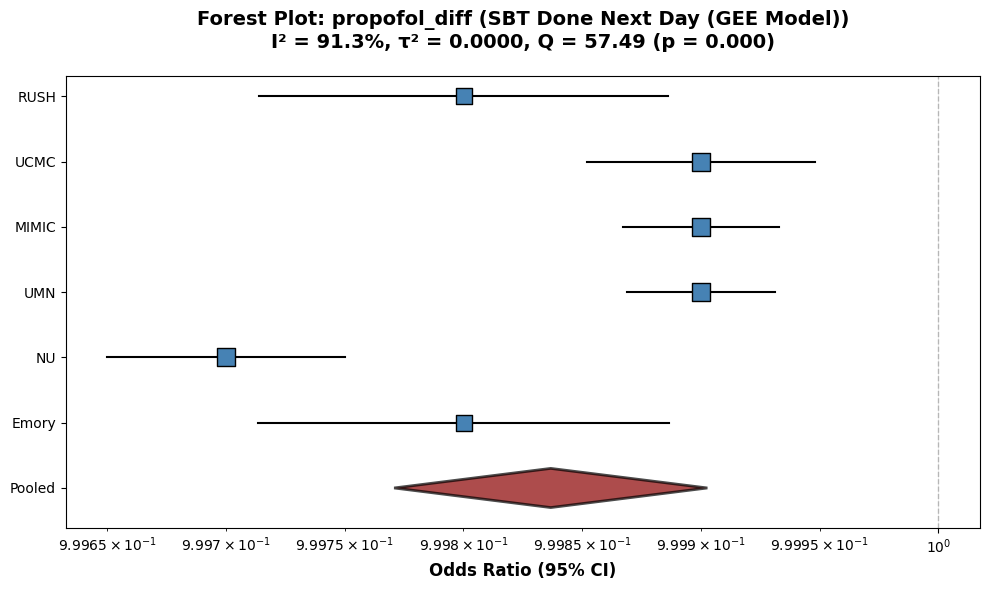


Creating forest plot for fentanyl_eq_diff...
Forest plot saved to: output/pooled/forest_plot_sbt_done_fentanyl_eq_diff_20251105_142350.png


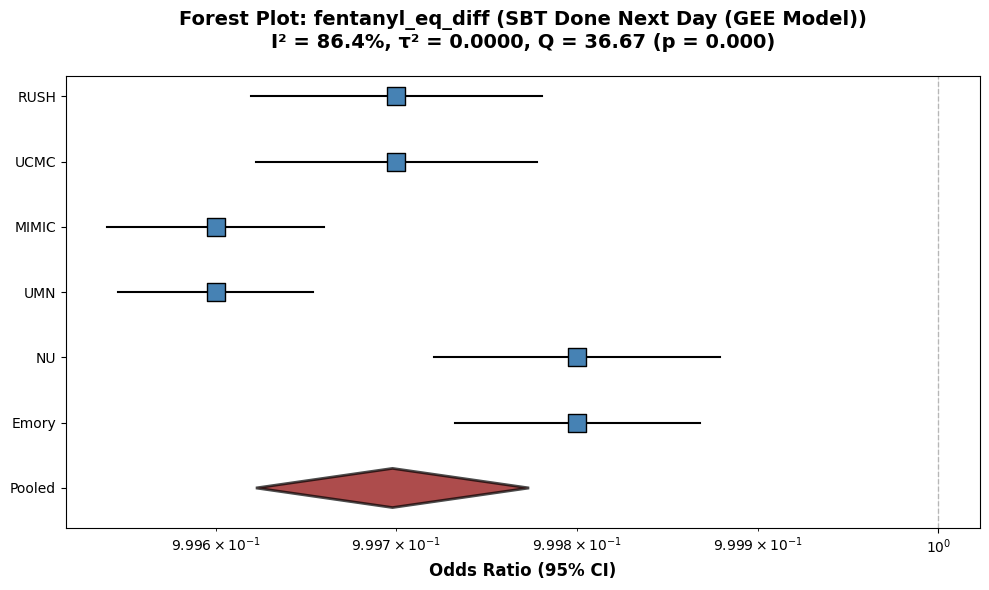


Creating forest plot for midazolam_eq_diff...
Forest plot saved to: output/pooled/forest_plot_sbt_done_midazolam_eq_diff_20251105_142350.png


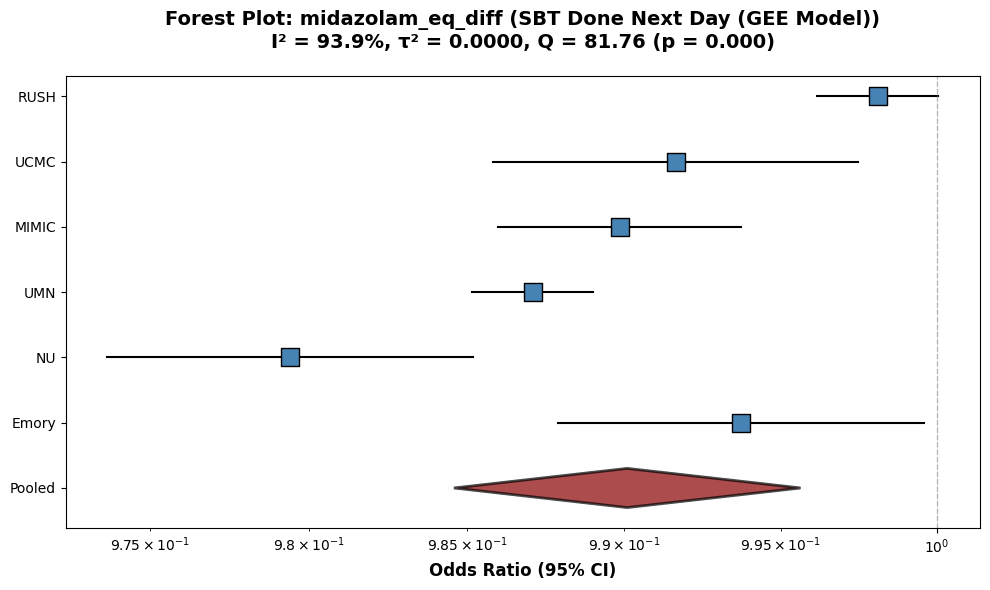


✓ Created 3 forest plot(s) for SBT Done Next Day (GEE Model)

Creating Forest Plots for Successful Extubation Next Day (Logit Model)

Creating forest plot for propofol_diff...
Forest plot saved to: output/pooled/forest_plot_success_extub_propofol_diff_20251105_142350.png


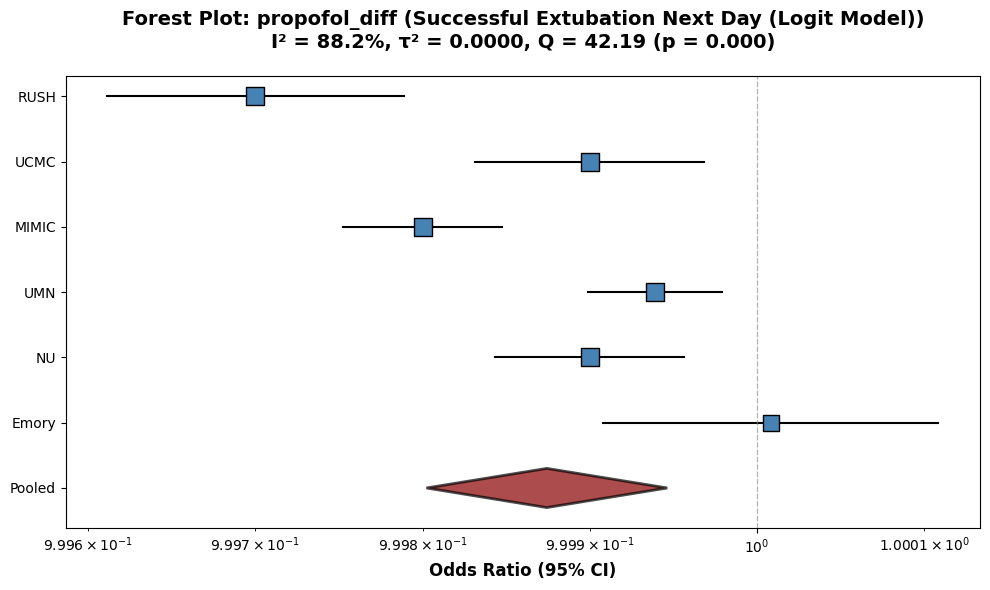


Creating forest plot for fentanyl_eq_diff...
Forest plot saved to: output/pooled/forest_plot_success_extub_fentanyl_eq_diff_20251105_142350.png


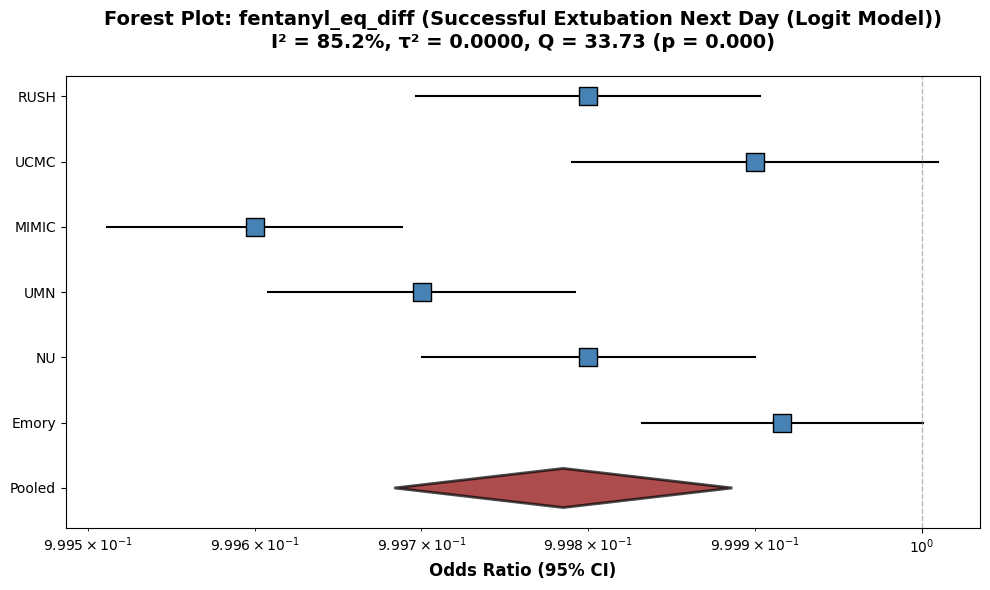


Creating forest plot for midazolam_eq_diff...
Forest plot saved to: output/pooled/forest_plot_success_extub_midazolam_eq_diff_20251105_142350.png


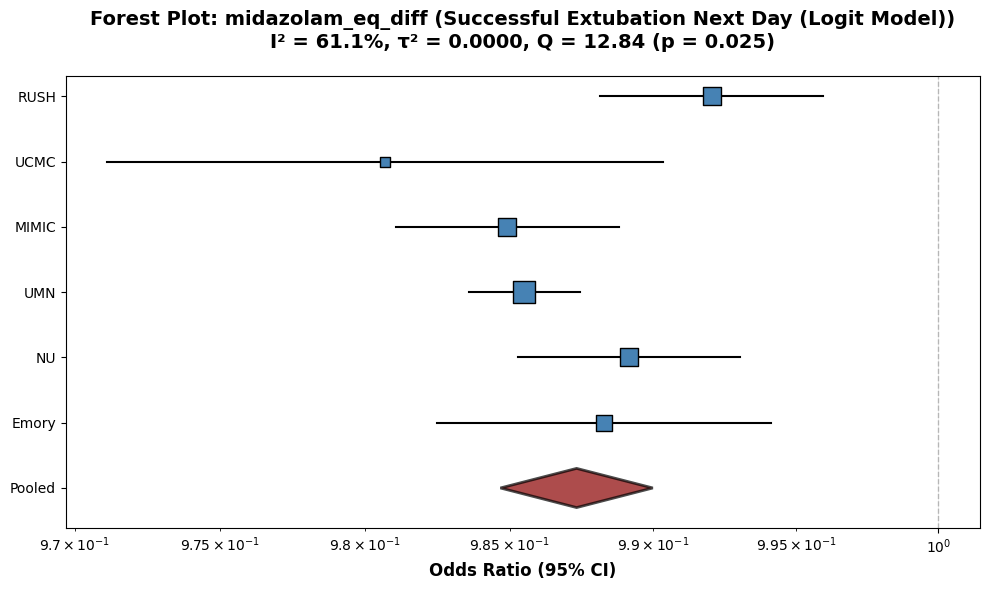


✓ Created 3 forest plot(s) for Successful Extubation Next Day (Logit Model)


In [8]:
# Create forest plots for each outcome type and variable
all_forest_plot_files = {}

for outcome_type, meta_results in all_meta_results.items():
    outcome_desc = OUTCOME_CONFIG[outcome_type]['description']
    print(f"\n{'='*70}")
    print(f"Creating Forest Plots for {outcome_desc}")
    print(f"{'='*70}")
    
    forest_plot_files = {}
    
    for var, results in meta_results.items():
        print(f"\nCreating forest plot for {var}...")
        
        # Create output filename with outcome type
        output_file = OUTPUT_DIR / f"forest_plot_{outcome_type}_{var}_{CURRENT_TIME_STR}.png"
        
        # Create forest plot
        fig, ax = create_forest_plot(results, f"{var} ({outcome_desc})", output_path=output_file)
        
        # Store filename
        forest_plot_files[var] = output_file
        
        # Display the plot
        plt.show()
        plt.close()
    
    all_forest_plot_files[outcome_type] = forest_plot_files
    print(f"\n✓ Created {len(forest_plot_files)} forest plot(s) for {outcome_desc}")


# 4. Export Results


In [9]:
# Export pooled results summary for each outcome type
all_pooled_outputs = {}

for outcome_type, meta_results in all_meta_results.items():
    outcome_desc = OUTCOME_CONFIG[outcome_type]['description']
    outcome_var = OUTCOME_CONFIG[outcome_type]['outcome_var']
    print(f"\n{'='*70}")
    print(f"Exporting Results for {outcome_desc}")
    print(f"{'='*70}")
    
    pooled_summary = []
    
    for var, results in meta_results.items():
        # Calculate pooled p-value
        pooled_z = results['pooled_effect'] / results['pooled_se']
        pooled_pval = 2 * (1 - stats.norm.cdf(abs(pooled_z)))
        
        pooled_summary.append({
            'outcome_type': outcome_type,
            'outcome_var': outcome_var,
            'variable': var,
            'log_or': results['pooled_effect'],
            'log_or_se': results['pooled_se'],
            'log_or_ci_lower': results['pooled_ci_lower'],
            'log_or_ci_upper': results['pooled_ci_upper'],
            'or': np.exp(results['pooled_effect']),
            'or_ci_lower': np.exp(results['pooled_ci_lower']),
            'or_ci_upper': np.exp(results['pooled_ci_upper']),
            'pval': pooled_pval,
            'n_studies': len(results['studies']),
            'tau2': results['tau2'],
            'Q': results['Q'],
            'Q_pval': results['Q_pval'],
            'I2': results['I2']
        })
    
    pooled_df = pd.DataFrame(pooled_summary)
    pooled_output = OUTPUT_DIR / f"meta_analysis_{outcome_type}_pooled_results_{CURRENT_TIME_STR}.csv"
    pooled_df.to_csv(pooled_output, index=False)
    print(f"✓ Saved pooled results to: {pooled_output}")
    
    all_pooled_outputs[outcome_type] = pooled_output
    
    # Display pooled results
    print("\nPooled Results Summary:")
    print(pooled_df.to_string(index=False))



Exporting Results for SBT Done Next Day (GEE Model)
✓ Saved pooled results to: output/pooled/meta_analysis_sbt_done_pooled_results_20251105_142350.csv

Pooled Results Summary:
outcome_type       outcome_var          variable    log_or  log_or_se  log_or_ci_lower  log_or_ci_upper       or  or_ci_lower  or_ci_upper         pval  n_studies         tau2         Q       Q_pval        I2
    sbt_done sbt_done_next_day     propofol_diff -0.000163   0.000034        -0.000229        -0.000097 0.999837     0.999771     0.999903 1.228007e-06          6 5.923618e-09 57.494889 3.998191e-11 91.303575
    sbt_done sbt_done_next_day  fentanyl_eq_diff -0.000302   0.000039        -0.000378        -0.000227 0.999698     0.999622     0.999773 4.884981e-15          6 7.651317e-09 36.673551 6.963184e-07 86.366196
    sbt_done sbt_done_next_day midazolam_eq_diff -0.009954   0.002845        -0.015531        -0.004377 0.990096     0.984589     0.995633 4.682755e-04          6 4.335135e-05 81.758303 3.330669e-

In [10]:
# Combine all pooled results and individual site results into a single DataFrame
all_pooled_dfs = []
all_site_dfs = []

for outcome_type in all_meta_results.keys():
    outcome_var = OUTCOME_CONFIG[outcome_type]['outcome_var']
    
    # Read the pooled results from CSV files
    pooled_file = OUTPUT_DIR / f"meta_analysis_{outcome_type}_pooled_results_{CURRENT_TIME_STR}.csv"
    if pooled_file.exists():
        df_pooled = pd.read_csv(pooled_file)
        df_pooled['site'] = 'pooled'  # Add site column for pooled results
        all_pooled_dfs.append(df_pooled)
    
    # Get individual site results from all_combined_data
    if outcome_type in all_combined_data:
        site_data = all_combined_data[outcome_type].copy()
        
        # Transform site data to match pooled format
        # site_data has: site, variable, coef, se, pval, outcome_type, variance
        # We need: outcome_type, outcome_var, variable, log_or, log_or_se, log_or_ci_lower, log_or_ci_upper, or, or_ci_lower, or_ci_upper, pval, site
        
        site_data['outcome_var'] = outcome_var
        site_data['log_or'] = site_data['coef']
        site_data['log_or_se'] = site_data['se']
        site_data['log_or_ci_lower'] = site_data['coef'] - 1.96 * site_data['se']
        site_data['log_or_ci_upper'] = site_data['coef'] + 1.96 * site_data['se']
        site_data['or'] = np.exp(site_data['coef'])
        site_data['or_ci_lower'] = np.exp(site_data['log_or_ci_lower'])
        site_data['or_ci_upper'] = np.exp(site_data['log_or_ci_upper'])
        
        all_site_dfs.append(site_data)

# Concatenate pooled and site-specific dataframes
all_dfs = all_pooled_dfs + all_site_dfs
pooled_df_combined = pd.concat(all_dfs, ignore_index=True)

# Keep only the specified columns
columns_to_keep = [
    'site', 'outcome_type', 'outcome_var', 'variable', 
    'log_or', 'log_or_se', 'log_or_ci_lower', 'log_or_ci_upper', 
    'or', 'or_ci_lower', 'or_ci_upper', 'pval'
]
pooled_df_combined = pooled_df_combined[columns_to_keep]

# Sort by outcome_type, variable, and site (pooled first)
pooled_df_combined['_site_sort'] = pooled_df_combined['site'].apply(lambda x: 0 if x == 'pooled' else 1)
pooled_df_combined = pooled_df_combined.sort_values(['outcome_type', 'variable', '_site_sort', 'site'])
pooled_df_combined = pooled_df_combined.drop(columns=['_site_sort'])

# Save combined results
pooled_output_combined = OUTPUT_DIR / f"meta_analysis_pooled_results_all_{CURRENT_TIME_STR}.csv"
pooled_df_combined.to_csv(pooled_output_combined, index=False)

print(f"\n{'='*70}")
print(f"✓ Saved combined pooled and site-specific results to: {pooled_output_combined}")
print(f"  Total rows: {len(pooled_df_combined)}")
print(f"  Sites: {sorted(pooled_df_combined['site'].unique().tolist())}")
print(f"  Outcomes: {pooled_df_combined['outcome_type'].unique().tolist()}")
print(f"  Variables: {pooled_df_combined['variable'].unique().tolist()}")
print(f"{'='*70}")

# Display combined results
print("\nCombined Pooled and Site-Specific Results Summary:")
print(pooled_df_combined.to_string(index=False))


✓ Saved combined pooled and site-specific results to: output/pooled/meta_analysis_pooled_results_all_20251105_142350.csv
  Total rows: 42
  Sites: ['Emory', 'MIMIC', 'NU', 'RUSH', 'UCMC', 'UMN', 'pooled']
  Outcomes: ['sbt_done', 'success_extub']
  Variables: ['fentanyl_eq_diff', 'midazolam_eq_diff', 'propofol_diff']

Combined Pooled and Site-Specific Results Summary:
  site  outcome_type            outcome_var          variable    log_or  log_or_se  log_or_ci_lower  log_or_ci_upper       or  or_ci_lower  or_ci_upper         pval
pooled      sbt_done      sbt_done_next_day  fentanyl_eq_diff -0.000302   0.000039        -0.000378    -2.265442e-04 0.999698     0.999622     0.999773 4.884981e-15
 Emory      sbt_done      sbt_done_next_day  fentanyl_eq_diff -0.000200   0.000035        -0.000268    -1.321840e-04 0.999800     0.999732     0.999868 0.000000e+00
 MIMIC      sbt_done      sbt_done_next_day  fentanyl_eq_diff -0.000400   0.000031        -0.000460    -3.400240e-04 0.999600     0.9

In [11]:
all_pooled_dfs[0]

,outcome_type,outcome_var,variable,log_or,log_or_se,log_or_ci_lower,log_or_ci_upper,or,or_ci_lower,or_ci_upper,pval,n_studies,tau2,Q,Q_pval,I2,site
0,sbt_done,sbt_done_next_day,propofol_diff,-0.000163,0.000034,-0.000229,-0.000097,0.999837,0.999771,0.999903,1.228007e-06,6,5.923618e-09,57.494889,3.998191e-11,91.303575,pooled
1,sbt_done,sbt_done_next_day,fentanyl_eq_diff,-0.000302,0.000039,-0.000378,-0.000227,0.999698,0.999622,0.999773,4.884981e-15,6,7.651317e-09,36.673551,6.963184e-07,86.366196,pooled
2,sbt_done,sbt_done_next_day,midazolam_eq_diff,-0.009954,0.002845,-0.015531,-0.004377,0.990096,0.984589,0.995633,4.682755e-04,6,4.335135e-05,81.758303,3.330669e-16,93.884413,pooled


In [12]:
# Export heterogeneity statistics for each outcome type
all_heterogeneity_outputs = {}

for outcome_type, meta_results in all_meta_results.items():
    outcome_desc = OUTCOME_CONFIG[outcome_type]['description']
    outcome_var = OUTCOME_CONFIG[outcome_type]['outcome_var']
    heterogeneity_stats = []
    
    for var, results in meta_results.items():
        heterogeneity_stats.append({
            'outcome_type': outcome_type,
            'outcome_var': outcome_var,
            'variable': var,
            'n_studies': len(results['studies']),
            'Q_statistic': results['Q'],
            'Q_pval': results['Q_pval'],
            'I2_percent': results['I2'],
            'tau2': results['tau2'],
            'heterogeneity_level': (
                'Low' if results['I2'] < 25 else
                'Moderate' if results['I2'] < 50 else
                'Substantial' if results['I2'] < 75 else
                'Considerable'
            )
        })
    
    heterogeneity_df = pd.DataFrame(heterogeneity_stats)
    heterogeneity_output = OUTPUT_DIR / f"heterogeneity_statistics_{outcome_type}_{CURRENT_TIME_STR}.csv"
    heterogeneity_df.to_csv(heterogeneity_output, index=False)
    print(f"\n✓ Saved {outcome_desc} heterogeneity statistics to: {heterogeneity_output}")
    
    all_heterogeneity_outputs[outcome_type] = heterogeneity_output
    
    # Display heterogeneity statistics
    print(f"\n{outcome_desc} Heterogeneity Statistics:")
    print(heterogeneity_df.to_string(index=False))



✓ Saved SBT Done Next Day (GEE Model) heterogeneity statistics to: output/pooled/heterogeneity_statistics_sbt_done_20251105_142350.csv

SBT Done Next Day (GEE Model) Heterogeneity Statistics:
outcome_type       outcome_var          variable  n_studies  Q_statistic       Q_pval  I2_percent         tau2 heterogeneity_level
    sbt_done sbt_done_next_day     propofol_diff          6    57.494889 3.998191e-11   91.303575 5.923618e-09        Considerable
    sbt_done sbt_done_next_day  fentanyl_eq_diff          6    36.673551 6.963184e-07   86.366196 7.651317e-09        Considerable
    sbt_done sbt_done_next_day midazolam_eq_diff          6    81.758303 3.330669e-16   93.884413 4.335135e-05        Considerable

✓ Saved Successful Extubation Next Day (Logit Model) heterogeneity statistics to: output/pooled/heterogeneity_statistics_success_extub_20251105_142350.csv

Successful Extubation Next Day (Logit Model) Heterogeneity Statistics:
 outcome_type            outcome_var          variable 

# Visualization



In [13]:
# Find and load hourly sedation dose files from all sites
def find_hourly_dose_files(box_root):
    """
    Find the most recent hourly dose files for each site.
    
    Parameters:
    -----------
    box_root : Path
        Root directory for Box files
        
    Returns:
    --------
    dict : Dictionary mapping site names to file paths
    """
    pattern = str(box_root / "*/final/*_sed_dose_by_hr_of_day_*.csv")
    dose_files = glob.glob(pattern)
    
    if not dose_files:
        print(f"Warning: No hourly dose files found matching pattern: {pattern}")
        return {}
    
    # Group files by site
    site_files = {}
    for filepath in dose_files:
        path_obj = Path(filepath)
        site_name = path_obj.parts[-3]  # Get site name from directory structure
        
        # Skip sites in SITES_TO_SKIP list
        if site_name in SITES_TO_SKIP:
            continue
        
        # Extract timestamp from filename
        filename = path_obj.name
        # Pattern: {site}_sed_dose_by_hr_of_day_{timestamp}.csv
        parts = filename.replace('.csv', '').split('_')
        if len(parts) >= 2:
            timestamp = parts[-1]  # Last part is timestamp
            
            if site_name not in site_files:
                site_files[site_name] = []
            site_files[site_name].append((timestamp, filepath))
    
    # Get the most recent file for each site
    latest_files = {}
    for site_name, files in site_files.items():
        # Sort by timestamp (descending) and get the most recent
        files.sort(reverse=True, key=lambda x: x[0])
        latest_files[site_name] = files[0][1]
    
    return latest_files

# Find all hourly dose files
hourly_dose_files = find_hourly_dose_files(BOX_ROOT)

print(f"\nFound {len(hourly_dose_files)} site(s) with hourly dose data:")
for site, filepath in hourly_dose_files.items():
    print(f"  - {site}: {Path(filepath).name}")



Found 6 site(s) with hourly dose data:
  - RUSH: rush_sed_dose_by_hr_of_day_20251105_110219.csv
  - UCMC: ucmc_sed_dose_by_hr_of_day_20251104_164214.csv
  - MIMIC: mimic_sed_dose_by_hr_of_day_20251104_164105.csv
  - UMN: umn_sed_dose_by_hr_of_day_20251105_051838.csv
  - NW: nu_sed_dose_by_hr_of_day_20251104_171900.csv
  - Emory: emory_sed_dose_by_hr_of_day_20251104_183253.csv


In [14]:
# Load and combine hourly dose data from all sites
all_hourly_data = []

for site_name, file_path in hourly_dose_files.items():
    try:
        # Read the CSV file
        df = pd.read_csv(file_path)
        
        # Check for required columns
        required_cols = ['_hr', 'propofol_mg', '_fentanyl_eq_mcg', '_midazolam_eq_mg']
        if all(col in df.columns for col in required_cols):
            df['site'] = site_name
            all_hourly_data.append(df[required_cols + ['site']])
            print(f"✓ Loaded {len(df)} hours from {site_name}")
        else:
            print(f"✗ Missing required columns in {site_name}")
    except Exception as e:
        print(f"✗ Error loading {site_name}: {str(e)}")

if all_hourly_data:
    # Combine all data
    combined_hourly_df = pd.concat(all_hourly_data, ignore_index=True)
    
    # Rename site NW to NU (typo correction)
    combined_hourly_df['site'] = combined_hourly_df['site'].replace({'NW': 'NU'})
    
    print(f"\n{len(combined_hourly_df)} total hourly observations loaded")
    print(f"Sites: {combined_hourly_df['site'].unique().tolist()}")
    print(f"Hours covered: {sorted(combined_hourly_df['_hr'].unique().tolist())}")
else:
    raise ValueError("No hourly dose data loaded from any site")


✓ Loaded 24 hours from RUSH
✓ Loaded 24 hours from UCMC
✓ Loaded 24 hours from MIMIC
✓ Loaded 24 hours from UMN
✓ Loaded 24 hours from NW
✓ Loaded 24 hours from Emory

144 total hourly observations loaded
Sites: ['RUSH', 'UCMC', 'MIMIC', 'UMN', 'NU', 'Emory']
Hours covered: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [15]:
# Create consistent site mapping and color scheme for all visualizations
print("\n" + "="*70)
print("CREATING CONSISTENT SITE MAPPING AND COLORS")
print("="*70)

# Get all unique sites from both hourly data and meta-analysis data
all_sites_hourly = set(combined_hourly_df['site'].unique()) if 'combined_hourly_df' in locals() else set()
all_sites_meta = set(pooled_df_combined['site'].unique()) if 'pooled_df_combined' in locals() else set()
all_sites_meta.discard('pooled')  # Remove 'pooled' from the set

# Combine and sort all unique sites, excluding sites in SITES_TO_SKIP
all_sites_combined = all_sites_hourly.union(all_sites_meta)
all_unique_sites = sorted([site for site in all_sites_combined if site not in SITES_TO_SKIP])

# Create consistent anonymization mapping
GLOBAL_SITE_MAPPING = {site: f"Site {chr(65 + i)}" for i, site in enumerate(all_unique_sites)}
GLOBAL_SITE_MAPPING['pooled'] = 'Pooled'

# Create consistent color palette (using Set2 for better visual appeal)
n_sites = len(all_unique_sites)
colors = sns.color_palette("Set2", n_sites)
GLOBAL_SITE_COLORS = dict(zip([GLOBAL_SITE_MAPPING[site] for site in all_unique_sites], colors))
GLOBAL_SITE_COLORS['Pooled'] = 'darkred'  # Special color for pooled

# Also create a mapping from original site names to colors for convenience
GLOBAL_SITE_COLORS_ORIGINAL = {site: GLOBAL_SITE_COLORS[GLOBAL_SITE_MAPPING[site]] for site in all_unique_sites}

print(f"\nSite Mapping:")
for orig_site in all_unique_sites:
    anon_site = GLOBAL_SITE_MAPPING[orig_site]
    print(f"  {orig_site:15} → {anon_site}")

print(f"\n✓ Created consistent mapping for {len(all_unique_sites)} sites")
print(f"✓ Color palette: Set2 (consistent across all visualizations)")

# Show skipped sites if any
skipped_in_data = [site for site in all_sites_combined if site in SITES_TO_SKIP]
if skipped_in_data:
    print(f"\n⚠ Skipped sites (from SITES_TO_SKIP): {', '.join(skipped_in_data)}")



CREATING CONSISTENT SITE MAPPING AND COLORS

Site Mapping:
  Emory           → Site A
  MIMIC           → Site B
  NU              → Site C
  RUSH            → Site D
  UCMC            → Site E
  UMN             → Site F

✓ Created consistent mapping for 6 sites
✓ Color palette: Set2 (consistent across all visualizations)



✓ Saved multi-site visualization to: output/pooled/multisite_hourly_sedation_doses_20251105_142350.png


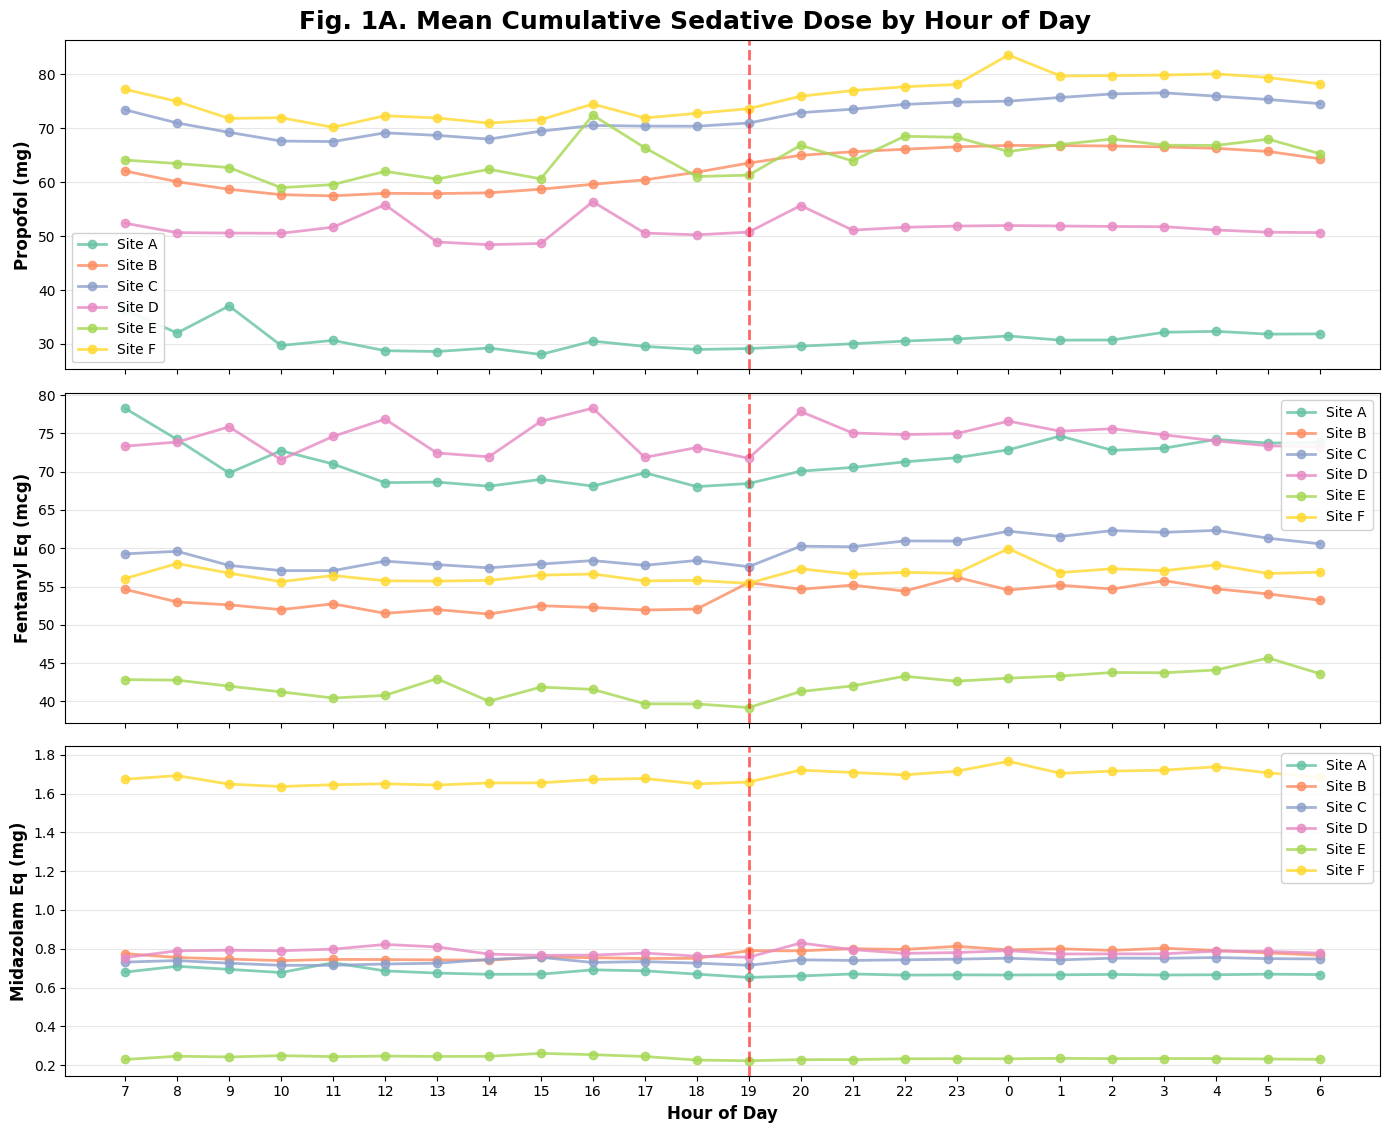

In [34]:
# Create multi-site line plot visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reorder hours to start from 7am (7,8,...,23,0,1,...,6)
def reorder_hours_for_display(df):
    """Reorder hours to start from 7am for display"""
    desired_order = list(range(7, 24)) + list(range(0, 7))
    
    # Create a mapping for sort order
    hour_order = {h: i for i, h in enumerate(desired_order)}
    df['_hour_order'] = df['_hr'].map(hour_order)
    
    # Sort by site and hour order
    df_sorted = df.sort_values(['site', '_hour_order'])
    
    return df_sorted, desired_order

combined_hourly_sorted, hour_order = reorder_hours_for_display(combined_hourly_df.copy())

# Create figure with 3 subplots (one for each drug)
fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Add a single overall title
fig.suptitle("Fig. 1A. Mean Cumulative Sedative Dose by Hour of Day", fontsize=18, fontweight='bold', y=0.94)

# Use consistent site mapping and colors
sites = sorted(combined_hourly_sorted['site'].unique())
# Map original site names to anonymized names for the legend
site_labels = {site: GLOBAL_SITE_MAPPING[site] for site in sites}
# Use the global color scheme
site_colors = GLOBAL_SITE_COLORS_ORIGINAL

# Plot 1: Propofol
for site in sites:
    site_data = combined_hourly_sorted[combined_hourly_sorted['site'] == site]
    axs[0].plot(site_data['_hour_order'], site_data['propofol_mg'], 
                marker='o', linewidth=2, label=site_labels[site], color=site_colors[site], alpha=0.8)

axs[0].set_ylabel('Propofol (mg)', fontsize=12, fontweight='bold')
# Removed panel-specific title
axs[0].grid(True, axis='y', alpha=0.3)
axs[0].legend(loc='best', framealpha=0.9)

# Plot 2: Fentanyl Equivalent
for site in sites:
    site_data = combined_hourly_sorted[combined_hourly_sorted['site'] == site]
    axs[1].plot(site_data['_hour_order'], site_data['_fentanyl_eq_mcg'], 
                marker='o', linewidth=2, label=site_labels[site], color=site_colors[site], alpha=0.8)

axs[1].set_ylabel('Fentanyl Eq (mcg)', fontsize=12, fontweight='bold')
# Removed panel-specific title
axs[1].grid(True, axis='y', alpha=0.3)
axs[1].legend(loc='best', framealpha=0.9)

# Plot 3: Midazolam Equivalent
for site in sites:
    site_data = combined_hourly_sorted[combined_hourly_sorted['site'] == site]
    axs[2].plot(site_data['_hour_order'], site_data['_midazolam_eq_mg'], 
                marker='o', linewidth=2, label=site_labels[site], color=site_colors[site], alpha=0.8)

axs[2].set_ylabel('Midazolam Eq (mg)', fontsize=12, fontweight='bold')
# Removed panel-specific title
axs[2].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
axs[2].grid(True, axis='y', alpha=0.3)
axs[2].legend(loc='best', framealpha=0.9)

# Add vertical line at 7pm (hour 19) to show shift change
for ax in axs:
    # Find position of hour 19 in the reordered sequence
    if 19 in hour_order:
        hour_19_pos = hour_order.index(19)
        ax.axvline(hour_19_pos, color='red', linestyle='--', linewidth=2, alpha=0.6, 
                  label='7pm (Shift Change)')

# Set x-axis labels to show actual hours
axs[2].set_xticks(range(len(hour_order)))
axs[2].set_xticklabels(hour_order, rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Leave room for suptitle

# Save the figure
output_file = OUTPUT_DIR / f"multisite_hourly_sedation_doses_{CURRENT_TIME_STR}.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved multi-site visualization to: {output_file}")

plt.show()


# New

In [17]:
prop_mask = pooled_df_combined['variable'].str.contains('propofol') # 100 mcg
fent_mask = pooled_df_combined['variable'].str.contains('fentanyl') # 100 mg
mid_mask = pooled_df_combined['variable'].str.contains('midazolam') # 1 mg

pooled_df_combined.loc[prop_mask, 'scaled_log_or'] = pooled_df_combined.loc[prop_mask, 'log_or'] * 100
pooled_df_combined.loc[fent_mask, 'scaled_log_or'] = pooled_df_combined.loc[fent_mask, 'log_or'] * 100
pooled_df_combined.loc[mid_mask, 'scaled_log_or'] = pooled_df_combined.loc[mid_mask, 'log_or']

pooled_df_combined.loc[prop_mask, 'scaled_log_or_ci_lower'] = pooled_df_combined.loc[prop_mask, 'log_or_ci_lower'] * 100
pooled_df_combined.loc[prop_mask, 'scaled_log_or_ci_upper'] = pooled_df_combined.loc[prop_mask, 'log_or_ci_upper'] * 100

pooled_df_combined.loc[fent_mask, 'scaled_log_or_ci_lower'] = pooled_df_combined.loc[fent_mask, 'log_or_ci_lower'] * 100
pooled_df_combined.loc[fent_mask, 'scaled_log_or_ci_upper'] = pooled_df_combined.loc[fent_mask, 'log_or_ci_upper'] * 100

pooled_df_combined.loc[mid_mask, 'scaled_log_or_ci_lower'] = pooled_df_combined.loc[mid_mask, 'log_or_ci_lower']
pooled_df_combined.loc[mid_mask, 'scaled_log_or_ci_upper'] = pooled_df_combined.loc[mid_mask, 'log_or_ci_upper']

In [18]:
pooled_df_combined['scaled_or'] = np.exp(pooled_df_combined['scaled_log_or'])
pooled_df_combined['scaled_or_ci_lower'] = np.exp(pooled_df_combined['scaled_log_or_ci_lower'])
pooled_df_combined['scaled_or_ci_upper'] = np.exp(pooled_df_combined['scaled_log_or_ci_upper'])

final_columns = ['site','outcome_type', 'variable', 'scaled_or', 'scaled_or_ci_lower', 'scaled_or_ci_upper', 'pval']

df_scaled = pooled_df_combined[final_columns]
df_scaled['diff_odds_pct'] = (df_scaled['scaled_or'] - 1) * 100
df_scaled.loc[prop_mask, 'unit_increase'] = '100 mg'
df_scaled.loc[fent_mask, 'unit_increase'] = '100 mcg'
df_scaled.loc[mid_mask, 'unit_increase'] = '1 mg'
df_scaled.sort_values(by=['variable', 'outcome_type'], ascending=False, inplace=True)

In [ ]:
def generate_or_text_concise(df_scaled):
    """
    Generate concise, publication-style interpretations of scaled odds ratios.
    Example output:
      "A 100 mg increase in propofol_diff is associated with a 1.2% decrease
       in the odds of performing SBT next day (OR=0.984, 95% CI 0.977–0.992, p<0.001)."
    """

    drug_map = {
        "fentanyl_eq_diff": ("fentanyl", "100 mcg"),
        "propofol_diff": ("propofol", "100 mg"),
        "midazolam_eq_diff": ("midazolam", "1 mg"),
    }
    outcome_map = {
        "sbt_done": "performing a spontaneous breathing trial (SBT) the next day",
        "success_extub": "successful extubation the next day"
    }

    sentences = []
    for _, row in df_scaled.query('site == "pooled"').iterrows():
        drug, unit = drug_map.get(row["variable"], (row["variable"], "1 unit"))
        outcome = outcome_map.get(row["outcome_type"], row["outcome_type"])
        or_val = row["scaled_or"]
        ci_lo, ci_hi = row["scaled_or_ci_lower"], row["scaled_or_ci_upper"]
        pct = abs(row["diff_odds_pct"])
        pval = row["pval"]

        # significance string
        if pval < 0.001:
            p_str = "p<0.001"
        elif pval < 0.01:
            p_str = "p<0.01"
        elif pval < 0.05:
            p_str = "p<0.05"
        else:
            p_str = f"p={pval:.2f}"

        direction = "increase" if row["diff_odds_pct"] > 0 else "decrease"

        text = (
            f"A {unit} increase in {drug} is associated with a "
            f"{pct:.1f}% {direction} in the odds of {outcome} "
            f"(OR={or_val:.3f}, 95% CI {ci_lo:.3f}–{ci_hi:.3f}, {p_str})."
        )
        sentences.append(text)

    return sentences

generate_or_text_concise(df_scaled)

['A 100 mg increase in propofol is associated with a 1.2% decrease in the odds of successful extubation the next day (OR=0.988, 95% CI 0.980–0.995, p<0.001).',
 'A 100 mg increase in propofol is associated with a 1.6% decrease in the odds of performing a spontaneous breathing trial (SBT) the next day (OR=0.984, 95% CI 0.977–0.990, p<0.001).',
 'A 1 mg increase in midazolam is associated with a 1.3% decrease in the odds of successful extubation the next day (OR=0.987, 95% CI 0.985–0.990, p<0.001).',
 'A 1 mg increase in midazolam is associated with a 1.0% decrease in the odds of performing a spontaneous breathing trial (SBT) the next day (OR=0.990, 95% CI 0.985–0.996, p<0.001).',
 'A 100 mcg increase in fentanyl is associated with a 2.1% decrease in the odds of successful extubation the next day (OR=0.979, 95% CI 0.969–0.989, p<0.001).',
 'A 100 mcg increase in fentanyl is associated with a 3.0% decrease in the odds of performing a spontaneous breathing trial (SBT) the next day (OR=0.97


✓ Saved faceted forest plot to: output/pooled/forest_plot_faceted_scaled_20251105_142350.png


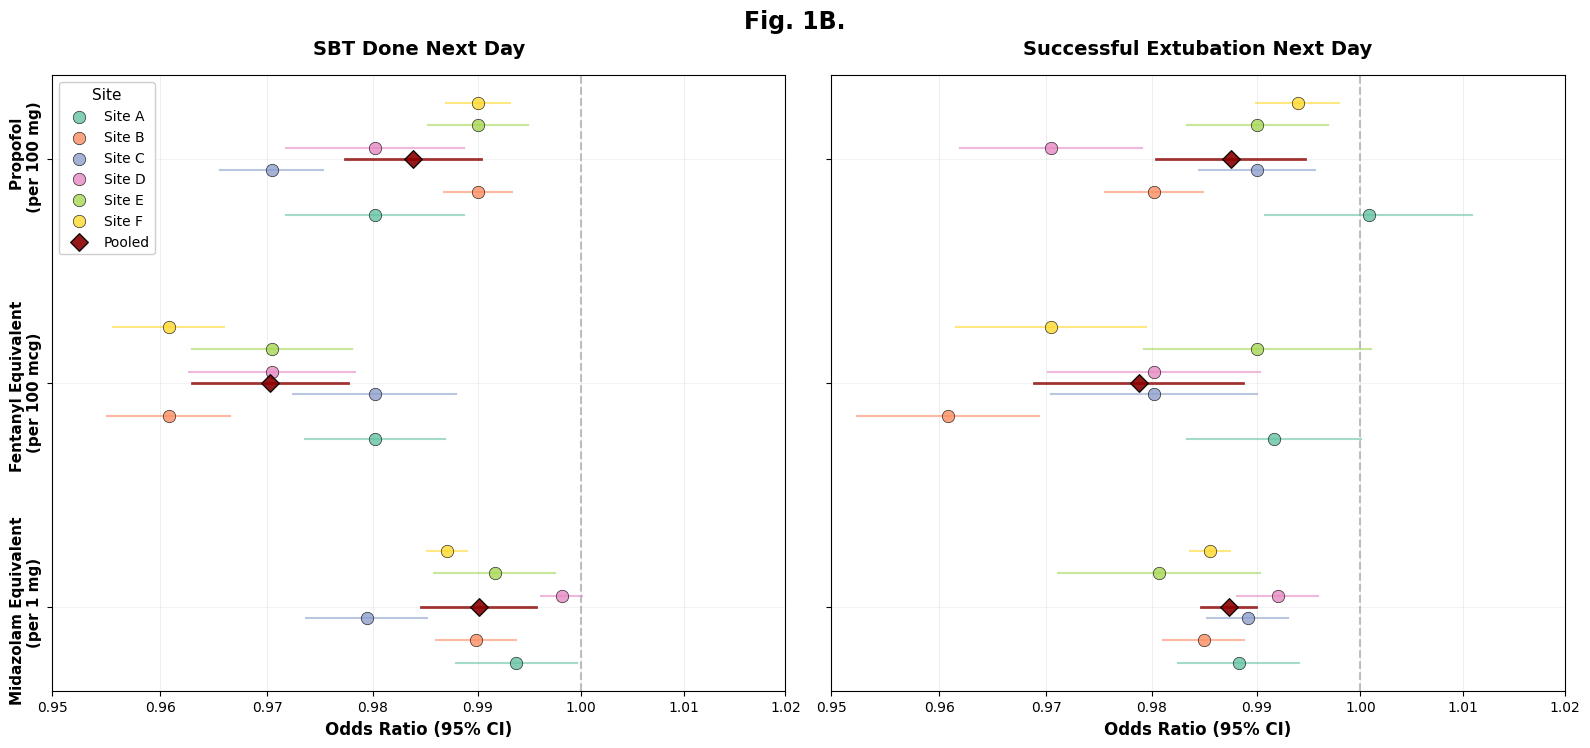

In [45]:
# Create faceted forest plot with anonymized sites

# 1. Use global site mapping (already created earlier)
df_plot = df_scaled.copy()

# Apply the global mapping
df_plot['site_anon'] = df_plot['site'].map(GLOBAL_SITE_MAPPING)
# 2. Set up plotting parameters
outcome_labels = {
    'sbt_done': 'SBT Done Next Day',
    'success_extub': 'Successful Extubation Next Day'
}

variable_labels = {
    'propofol_diff': 'Propofol   \n (per 100 mg)',
    'fentanyl_eq_diff': 'Fentanyl Equivalent \n(per 100 mcg)       ',
    'midazolam_eq_diff': 'Midazolam Equivalent \n(per 1 mg)         '
}

# Order variables for y-axis
var_order = ['propofol_diff', 'fentanyl_eq_diff', 'midazolam_eq_diff']

# 3. Create figure with 2 subplots (one per outcome)
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Use the global color scheme
anon_sites = sorted([s for s in df_plot['site_anon'].unique() if s != 'Pooled'])
site_colors = GLOBAL_SITE_COLORS  # Use the global color mapping

# Marker styles
markers = {'Pooled': 'D'}  # Diamond for pooled
for site in anon_sites:
    markers[site] = 'o'  # Circle for individual sites

# 4. Create plots for each outcome
outcomes = ['sbt_done', 'success_extub']

for idx, outcome in enumerate(outcomes):
    ax = axes[idx]
    
    # Filter data for this outcome
    df_outcome = df_plot[df_plot['outcome_type'] == outcome].copy()
    
    # Create y-position mapping for variables
    y_positions = {var: i * 1.5 for i, var in enumerate(reversed(var_order))}
    
    # Plot each site's estimates
    for var in var_order:
        df_var = df_outcome[df_outcome['variable'] == var]
        y_base = y_positions[var]
        
        # Separate pooled and individual sites
        df_pooled = df_var[df_var['site_anon'] == 'Pooled']
        df_sites = df_var[df_var['site_anon'] != 'Pooled']
        
        # Plot individual sites (offset from center)
        n_sites_var = len(df_sites)
        if n_sites_var > 0:
            offset_step = 0.15
            offsets = np.linspace(-offset_step * (n_sites_var - 1) / 2, 
                                 offset_step * (n_sites_var - 1) / 2, 
                                 n_sites_var)
            
            for i, (_, row) in enumerate(df_sites.iterrows()):
                y_pos = y_base + offsets[i]
                site = row['site_anon']
                
                # Plot CI line
                ax.plot([row['scaled_or_ci_lower'], row['scaled_or_ci_upper']], 
                       [y_pos, y_pos], 
                       color=site_colors[site], linewidth=1.5, alpha=0.6, zorder=1)
                
                # Plot point estimate
                ax.scatter(row['scaled_or'], y_pos, 
                          marker=markers[site], s=80, 
                          color=site_colors[site], 
                          edgecolors='black', linewidths=0.5,
                          alpha=0.8, zorder=2,
                          label=site if var == var_order[0] else "")
        
        # Plot pooled estimate (on center line, larger)
        if len(df_pooled) > 0:
            row = df_pooled.iloc[0]
            
            # Plot CI line (thicker)
            ax.plot([row['scaled_or_ci_lower'], row['scaled_or_ci_upper']], 
                   [y_base, y_base], 
                   color=site_colors['Pooled'], linewidth=2.0, alpha=0.8, zorder=3)
            
            # Plot diamond
            ax.scatter(row['scaled_or'], y_base, 
                      marker=markers['Pooled'], s=80, 
                      color=site_colors['Pooled'], 
                      edgecolors='black', linewidths=1.0,
                      alpha=0.9, zorder=4,
                      label='Pooled' if var == var_order[0] else "")
    
    # Add vertical line at OR = 1 (null effect)
    ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, zorder=0)
    
    # Set y-axis
    ax.set_yticks([y_positions[var] for var in reversed(var_order)])
    ax.set_yticklabels([variable_labels[var] for var in reversed(var_order)], 
                       fontsize=11, fontweight='bold', rotation=90, va='center')
    
    # Do NOT add a superfluous y-axis label
    ax.set_ylabel("")  # No y-axis label
    
    # Set x-axis to log scale with readable decimal formatting
    ax.set_xscale('log')
    ax.set_xlabel('Odds Ratio (95% CI)', fontsize=12, fontweight='bold')
    
    # Format x-axis tick labels to show decimals instead of scientific notation
    def decimal_formatter(x, pos):
        return f'{x:.2f}'
    ax.xaxis.set_major_formatter(FuncFormatter(decimal_formatter))
    ax.tick_params(axis='x', labelsize=10)

    # Set x-axis limits to 0.95 to 1.02 for both panels
    ax.set_xlim([0.95, 1.02])
    # Set custom ticks in that range
    x_ticks = np.arange(0.95, 1.021, 0.01)
    ax.set_xticks(x_ticks)
    
    # Set title
    ax.set_title(outcome_labels[outcome], fontsize=14, fontweight='bold', pad=15)
    
    # Add grid
    ax.grid(True, axis='x', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.grid(True, axis='y', alpha=0.2, linestyle='-', linewidth=0.5)
    
    # Add legend (only on first subplot)
    if idx == 0:
        handles, labels = ax.get_legend_handles_labels()
        # Remove duplicates while preserving order
        by_label = dict(zip(labels, handles))
        # Reorder so Pooled is last
        ordered_labels = [l for l in by_label.keys() if l != 'Pooled'] + ['Pooled']
        ordered_handles = [by_label[l] for l in ordered_labels]
        ax.legend(ordered_handles, ordered_labels, 
                 loc='upper left', framealpha=0.95, 
                 fontsize=10, title='Site', title_fontsize=11)

# Add overall figure title "Fig. 1B."
fig.suptitle('Fig. 1B.', fontsize=17, fontweight='bold', y=0.93)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save figure
output_file = OUTPUT_DIR / f"forest_plot_faceted_scaled_{CURRENT_TIME_STR}.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved faceted forest plot to: {output_file}")

plt.show()


# 6. Pooled Table 1


In [21]:
# Helper functions for pooling Table 1 data
import re

def pooled_mean_sd(means, sds, ns):
    """
    Calculate pooled mean and standard deviation across multiple sites.
    
    Parameters:
    -----------
    means : array-like
        Means from each site
    sds : array-like
        Standard deviations from each site
    ns : array-like
        Sample sizes from each site
        
    Returns:
    --------
    tuple : (pooled_mean, pooled_sd)
    """
    means = np.array(list(means), dtype=float)
    sds = np.array(list(sds), dtype=float)
    ns = np.array(list(ns), dtype=float)
    
    N = ns.sum()
    if N <= 1:
        return np.nan, np.nan
    
    # Pooled mean
    mean = (means * ns).sum() / N
    
    # Pooled variance using the formula for combining variances
    var = (((ns - 1) * (sds**2)).sum() + (ns * (means - mean)**2).sum()) / (N - 1)
    sd = np.sqrt(var)
    
    return mean, sd

print("✓ Pooling functions loaded successfully.")


✓ Pooling functions loaded successfully.


In [22]:
def pool_by_shift_tables(paths):
    """
    Pool Table 1 by shift data from multiple sites.
    
    Parameters:
    -----------
    paths : list
        List of file paths to site-specific table one by shift CSV files
        
    Returns:
    --------
    tuple : (pooled_continuous_df, pooled_categorical_df)
    """
    cont_frames = []
    cat_frames = []
    
    for p in paths:
        site = os.path.basename(p).split("_")[0]
        df = pd.read_csv(p).rename(columns={
            "Grouped by _shift.1": "Overall",
            "Grouped by _shift.2": "day",
            "Grouped by _shift.3": "night",
            "Grouped by _shift.4": "P-Value"
        })
        
        # Extract sample sizes
        nrow = df[df["Unnamed: 0"] == "n"].iloc[0]
        n_overall = int(nrow["Overall"])
        n_day = int(nrow["day"])
        n_night = int(nrow["night"])
        
        # Process continuous variables (mean (SD))
        cont = df[df["Unnamed: 0"].str.contains(r"mean \(SD\)", na=False)].copy()
        cont["variable"] = cont["Unnamed: 0"].str.replace(r", mean \(SD\)", "", regex=True)
        
        def parse_msd(s):
            """Parse 'mean (sd)' format"""
            if pd.isna(s):
                return (np.nan, np.nan)
            vals = re.findall(r"[-]?\d+\.?\d*", str(s))
            return (float(vals[0]), float(vals[1])) if len(vals) >= 2 else (np.nan, np.nan)
        
        for col, n in [("Overall", n_overall), ("day", n_day), ("night", n_night)]:
            parsed = cont[col].apply(parse_msd).tolist()
            cont[f"{col}_mean"] = [t[0] for t in parsed]
            cont[f"{col}_sd"] = [t[1] for t in parsed]
            cont[f"{col}_n"] = n
        
        cont["site"] = site
        cont_frames.append(cont[["site", "variable",
                                 "Overall_mean", "Overall_sd", "Overall_n",
                                 "day_mean", "day_sd", "day_n",
                                 "night_mean", "night_sd", "night_n"]])
        
        # Process categorical variables (n (%))
        cat = df[df["Unnamed: 0"].str.contains(r", n \(%\)", na=False)].copy()
        if not cat.empty:
            cat["variable"] = cat["Unnamed: 0"].str.replace(r", n \(%\)", "", regex=True)
            cat["level"] = cat["Unnamed: 1"]
            
            def parse_cp(s):
                """Parse 'count (percent)' format"""
                if pd.isna(s):
                    return (np.nan, np.nan)
                m = re.match(r"\s*([\-]?\d+)\s*\(([\-]?\d+\.?\d*)\)", str(s))
                return (int(m.group(1)), float(m.group(2))) if m else (np.nan, np.nan)
            
            for col in ["Overall", "day", "night"]:
                parsed = cat[col].apply(parse_cp).tolist()
                cat[f"{col}_count"] = [t[0] for t in parsed]
            
            cat["site"] = site
            cat_frames.append(cat[["site", "variable", "level",
                                  "Overall_count", "day_count", "night_count"]])
    
    # Pool continuous variables
    cont_all = pd.concat(cont_frames, ignore_index=True) if cont_frames else pd.DataFrame()
    pooled_cont = []
    
    for var, g in cont_all.groupby("variable"):
        row = {"variable": var}
        for col in ["Overall", "day", "night"]:
            m, s = pooled_mean_sd(g[f"{col}_mean"], g[f"{col}_sd"], g[f"{col}_n"])
            row[col] = f"{m:.1f} ({s:.1f})"
            row[f"{col}_n"] = int(g[f"{col}_n"].iloc[0])  # All should be same, take first
        pooled_cont.append(row)
    
    pooled_cont_df = pd.DataFrame(pooled_cont)
    
    # Pool categorical variables
    cat_all = pd.concat(cat_frames, ignore_index=True) if cat_frames else pd.DataFrame()
    
    if not cat_all.empty:
        pooled_cat = (cat_all.groupby(["variable", "level"])
                      .agg(Overall_count=("Overall_count", "sum"),
                           day_count=("day_count", "sum"),
                           night_count=("night_count", "sum"))
                      .reset_index())
        
        # Calculate denominators (total for each variable)
        totals = pooled_cat.groupby("variable")[["Overall_count", "day_count", "night_count"]].sum().rename(
            columns={"Overall_count": "Overall_denom",
                    "day_count": "day_denom",
                    "night_count": "night_denom"}).reset_index()
        
        pooled_cat = pooled_cat.merge(totals, on="variable")
        
        # Calculate percentages
        for col in ["Overall", "day", "night"]:
            pooled_cat[f"{col}_pct"] = (pooled_cat[f"{col}_count"] / pooled_cat[f"{col}_denom"] * 100).round(1)
            pooled_cat[col] = pooled_cat.apply(
                lambda row: f"{int(row[f'{col}_count'])} ({row[f'{col}_pct']:.1f})", axis=1)
    else:
        pooled_cat = pd.DataFrame()
    
    return pooled_cont_df, pooled_cat

print("✓ Pool by shift function loaded successfully.")


✓ Pool by shift function loaded successfully.


In [23]:
def pool_overall_tables(paths):
    """
    Pool overall Table 1 data from multiple sites.
    
    Parameters:
    -----------
    paths : list
        List of file paths to site-specific overall table one CSV files
        
    Returns:
    --------
    tuple : (pooled_continuous_df, pooled_categorical_df)
    """
    cont_frames = []
    cat_frames = []
    
    for p in paths:
        site = os.path.basename(p).split("_")[0]
        df = pd.read_csv(p)
        
        # Extract sample size
        nrow = df[df["Unnamed: 0"] == "n"].iloc[0]
        n = int(nrow["Overall"])
        
        # Process continuous variables (mean (SD))
        cont = df[df["Unnamed: 0"].str.contains(r"mean \(SD\)", na=False)].copy()
        cont["variable"] = cont["Unnamed: 0"].str.replace(r", mean \(SD\)", "", regex=True)
        
        def parse_msd(s):
            """Parse 'mean (sd)' format"""
            if pd.isna(s):
                return (np.nan, np.nan)
            vals = re.findall(r"[-]?\d+\.?\d*", str(s))
            return (float(vals[0]), float(vals[1])) if len(vals) >= 2 else (np.nan, np.nan)
        
        parsed = cont["Overall"].apply(parse_msd).tolist()
        cont["mean"] = [t[0] for t in parsed]
        cont["sd"] = [t[1] for t in parsed]
        cont["n"] = n
        cont["site"] = site
        
        cont_frames.append(cont[["site", "variable", "mean", "sd", "n"]])
        
        # Process categorical variables (n (%))
        cat = df[df["Unnamed: 0"].str.contains(r", n \(%\)", na=False)].copy()
        if not cat.empty:
            cat["variable"] = cat["Unnamed: 0"].str.replace(r", n \(%\)", "", regex=True)
            cat["level"] = cat["Unnamed: 1"]
            
            def parse_cp(s):
                """Parse 'count (percent)' format"""
                if pd.isna(s):
                    return (np.nan, np.nan)
                m = re.match(r"\s*([\-]?\d+)\s*\(([\-]?\d+\.?\d*)\)", str(s))
                return (int(m.group(1)), float(m.group(2))) if m else (np.nan, np.nan)
            
            parsed = cat["Overall"].apply(parse_cp).tolist()
            cat["count"] = [t[0] for t in parsed]
            cat["site"] = site
            
            cat_frames.append(cat[["site", "variable", "level", "count"]])
    
    # Pool continuous variables
    cont_all = pd.concat(cont_frames, ignore_index=True) if cont_frames else pd.DataFrame()
    pooled_cont = []
    
    for var, g in cont_all.groupby("variable"):
        m, s = pooled_mean_sd(g["mean"], g["sd"], g["n"])
        n_total = int(g["n"].sum())
        pooled_cont.append({
            "variable": var,
            "Overall": f"{m:.1f} ({s:.1f})",
            "n": n_total
        })
    
    pooled_cont_df = pd.DataFrame(pooled_cont)
    
    # Pool categorical variables
    cat_all = pd.concat(cat_frames, ignore_index=True) if cat_frames else pd.DataFrame()
    
    if not cat_all.empty:
        pooled_cat = (cat_all.groupby(["variable", "level"])
                      .agg(count=("count", "sum"))
                      .reset_index())
        
        # Calculate denominators
        totals = pooled_cat.groupby("variable")["count"].sum().rename("denom").reset_index()
        pooled_cat = pooled_cat.merge(totals, on="variable")
        
        # Calculate percentages
        pooled_cat["pct"] = (pooled_cat["count"] / pooled_cat["denom"] * 100).round(1)
        pooled_cat["Overall"] = pooled_cat.apply(
            lambda row: f"{int(row['count'])} ({row['pct']:.1f})", axis=1)
    else:
        pooled_cat = pd.DataFrame()
    
    return pooled_cont_df, pooled_cat

print("✓ Pool overall function loaded successfully.")


✓ Pool overall function loaded successfully.


In [24]:
# Find Table 1 files from all sites
def find_table_one_files(box_root, table_type='by_shift'):
    """
    Find the most recent Table 1 files for each site.
    
    Parameters:
    -----------
    box_root : Path
        Root directory for Box files
    table_type : str
        Type of table: 'by_shift' or 'overall'
        
    Returns:
    --------
    list : List of file paths to the most recent table one files
    """
    if table_type == 'by_shift':
        pattern = str(box_root / "*/final/*_table_one_day_1_by_shift_*.csv")
    else:  # overall
        pattern = str(box_root / "*/final/*_table_one_day_1_*.csv")
        # Exclude the by_shift files
        all_files = glob.glob(pattern)
        all_files = [f for f in all_files if 'by_shift' not in f]
        pattern = None
    
    if pattern:
        table_files = glob.glob(pattern)
    else:
        table_files = all_files
    
    if not table_files:
        print(f"Warning: No {table_type} table one files found matching pattern")
        return []
    
    # Group files by site and get most recent
    site_files = {}
    for filepath in table_files:
        path_obj = Path(filepath)
        site_name = path_obj.parts[-3]  # Get site name from directory structure
        
        # Skip sites in SITES_TO_SKIP list
        if site_name in SITES_TO_SKIP:
            continue
        
        # Extract timestamp from filename
        filename = path_obj.name
        parts = filename.replace('.csv', '').split('_')
        timestamp = parts[-1]  # Last part is timestamp
        
        if site_name not in site_files:
            site_files[site_name] = []
        site_files[site_name].append((timestamp, filepath))
    
    # Get the most recent file for each site
    latest_files = []
    for site_name, files in site_files.items():
        # Sort by timestamp (descending) and get the most recent
        files.sort(reverse=True, key=lambda x: x[0])
        latest_files.append(files[0][1])
    
    return latest_files

# Find all table one files
print("\n" + "="*70)
print("FINDING TABLE 1 FILES")
print("="*70)

by_shift_files = find_table_one_files(BOX_ROOT, 'by_shift')
print(f"\nFound {len(by_shift_files)} site(s) with Table 1 by shift:")
for filepath in by_shift_files:
    site = Path(filepath).parts[-3]
    print(f"  - {site}: {Path(filepath).name}")

overall_files = find_table_one_files(BOX_ROOT, 'overall')
print(f"\nFound {len(overall_files)} site(s) with overall Table 1:")
for filepath in overall_files:
    site = Path(filepath).parts[-3]
    print(f"  - {site}: {Path(filepath).name}")



FINDING TABLE 1 FILES

Found 6 site(s) with Table 1 by shift:
  - RUSH: rush_table_one_day_1_by_shift_20251105_110219.csv
  - UCMC: ucmc_table_one_day_1_by_shift_20251104_164214.csv
  - MIMIC: mimic_table_one_day_1_by_shift_20251104_164105.csv
  - UMN: umn_table_one_day_1_by_shift_20251105_051838.csv
  - NW: nu_table_one_day_1_by_shift_20251104_171900.csv
  - Emory: emory_table_one_day_1_by_shift_20251104_183253.csv

Found 6 site(s) with overall Table 1:
  - RUSH: rush_table_one_day_1_20251105_110219.csv
  - UCMC: ucmc_table_one_day_1_20251104_164214.csv
  - MIMIC: mimic_table_one_day_1_20251104_164105.csv
  - UMN: umn_table_one_day_1_20251105_051838.csv
  - NW: nu_table_one_day_1_20251104_171900.csv
  - Emory: emory_table_one_day_1_20251104_183253.csv


In [25]:
# Pool Table 1 by shift
print("\n" + "="*70)
print("POOLING TABLE 1 BY SHIFT")
print("="*70)

if by_shift_files:
    pooled_cont_shift, pooled_cat_shift = pool_by_shift_tables(by_shift_files)
    
    # Save results
    pooled_cont_shift_path = OUTPUT_DIR / f"pooled_table_one_day_1_by_shift_continuous_{CURRENT_TIME_STR}.csv"
    pooled_cat_shift_path = OUTPUT_DIR / f"pooled_table_one_day_1_by_shift_categorical_{CURRENT_TIME_STR}.csv"
    
    pooled_cont_shift.to_csv(pooled_cont_shift_path, index=False)
    pooled_cat_shift.to_csv(pooled_cat_shift_path, index=False)
    
    print(f"\n✓ Saved pooled continuous Table 1 by shift to: {pooled_cont_shift_path}")
    print(f"✓ Saved pooled categorical Table 1 by shift to: {pooled_cat_shift_path}")
    
    print("\nPooled Table 1 by Shift (Continuous):")
    print(pooled_cont_shift.to_string(index=False))
    
    if not pooled_cat_shift.empty:
        print("\nPooled Table 1 by Shift (Categorical):")
        print(pooled_cat_shift[["variable", "level", "Overall", "day", "night"]].to_string(index=False))
else:
    print("\nNo Table 1 by shift files found to pool.")



POOLING TABLE 1 BY SHIFT

✓ Saved pooled continuous Table 1 by shift to: output/pooled/pooled_table_one_day_1_by_shift_continuous_20251105_142350.csv
✓ Saved pooled categorical Table 1 by shift to: output/pooled/pooled_table_one_day_1_by_shift_categorical_20251105_142350.csv

Pooled Table 1 by Shift (Continuous):
             variable        Overall  Overall_n            day  day_n          night  night_n
                 _nee     0.5 (36.8)      13012     0.7 (39.7)   6506     0.4 (33.5)     6506
fentanyl_eq_mcg_total  664.5 (879.9)      13012  641.3 (882.8)   6506  687.7 (876.5)     6506
midazolam_eq_mg_total     8.9 (32.2)      13012     8.6 (29.5)   6506     9.1 (34.6)     6506
                   pf  313.9 (218.0)      13012  305.2 (217.4)   6506  322.5 (218.5)     6506
                   ph      7.4 (0.2)      13012      7.4 (0.2)   6506      7.4 (0.2)     6506
    propofol_mg_total 981.3 (1308.8)      13012 992.5 (1287.3)   6506 970.0 (1329.8)     6506

Pooled Table 1 by Shift (

In [26]:
# Pool overall Table 1
print("\n" + "="*70)
print("POOLING OVERALL TABLE 1")
print("="*70)

if overall_files:
    pooled_cont_overall, pooled_cat_overall = pool_overall_tables(overall_files)
    
    # Save results
    pooled_cont_overall_path = OUTPUT_DIR / f"pooled_table_one_day_1_continuous_{CURRENT_TIME_STR}.csv"
    pooled_cat_overall_path = OUTPUT_DIR / f"pooled_table_one_day_1_categorical_{CURRENT_TIME_STR}.csv"
    
    pooled_cont_overall.to_csv(pooled_cont_overall_path, index=False)
    pooled_cat_overall.to_csv(pooled_cat_overall_path, index=False)
    
    print(f"\n✓ Saved pooled continuous overall Table 1 to: {pooled_cont_overall_path}")
    print(f"✓ Saved pooled categorical overall Table 1 to: {pooled_cat_overall_path}")
    
    print("\nPooled Overall Table 1 (Continuous):")
    print(pooled_cont_overall.to_string(index=False))
    
    if not pooled_cat_overall.empty:
        print("\nPooled Overall Table 1 (Categorical):")
        print(pooled_cat_overall[["variable", "level", "Overall"]].to_string(index=False))
else:
    print("\nNo overall Table 1 files found to pool.")

print("\n" + "="*70)
print("TABLE 1 POOLING COMPLETE")
print("="*70)



POOLING OVERALL TABLE 1

✓ Saved pooled continuous overall Table 1 to: output/pooled/pooled_table_one_day_1_continuous_20251105_142350.csv
✓ Saved pooled categorical overall Table 1 to: output/pooled/pooled_table_one_day_1_categorical_20251105_142350.csv

Pooled Overall Table 1 (Continuous):
         variable       Overall     n
              age   60.7 (16.4) 71970
 fentanyl_eq_diff  46.4 (473.6) 71970
midazolam_eq_diff    0.5 (15.8) 71970
    propofol_diff -22.4 (637.7) 71970

Pooled Overall Table 1 (Categorical):
            variable  level      Overall
     _sbt_done_today    0.0 58051 (80.7)
     _sbt_done_today    1.0 13919 (19.3)
_success_extub_today    0.0 71810 (99.8)
_success_extub_today    1.0    160 (0.2)

TABLE 1 POOLING COMPLETE


# Final Summary

In [27]:
# Final Summary
print("\n" + "#"*70)
print("META-ANALYSIS COMPLETE")
print("#"*70)

for outcome_type in all_meta_results.keys():
    outcome_desc = OUTCOME_CONFIG[outcome_type]['description']
    outcome_var = OUTCOME_CONFIG[outcome_type]['outcome_var']
    
    print(f"\n{'='*70}")
    print(f"{outcome_desc}")
    print(f"Outcome Variable: {outcome_var}")
    print(f"{'='*70}")
    
    # Get site info
    site_files = all_outcome_files[outcome_type]
    print(f"\nSites analyzed: {len(site_files)}")
    for site in site_files.keys():
        print(f"  - {site}")
    
    # Get variable info
    meta_results = all_meta_results[outcome_type]
    print(f"\nPredictors analyzed: {len(meta_results)}")
    for var in meta_results.keys():
        print(f"  - {var}")
    
    print(f"\nOutput directory: {OUTPUT_DIR}")
    print("\nGenerated files:")
    print(f"  1. Pooled results: {all_pooled_outputs[outcome_type].name}")
    print(f"  2. Heterogeneity statistics: {all_heterogeneity_outputs[outcome_type].name}")
    
    forest_plot_files = all_forest_plot_files[outcome_type]
    for i, (var, filepath) in enumerate(forest_plot_files.items(), start=3):
        print(f"  {i}. Forest plot ({var}): {filepath.name}")

print("\n" + "#"*70)
print("All results saved successfully!")
print("#"*70)



######################################################################
META-ANALYSIS COMPLETE
######################################################################

SBT Done Next Day (GEE Model)
Outcome Variable: sbt_done_next_day

Sites analyzed: 6
  - RUSH
  - UCMC
  - MIMIC
  - UMN
  - NW
  - Emory

Predictors analyzed: 3
  - propofol_diff
  - fentanyl_eq_diff
  - midazolam_eq_diff

Output directory: output/pooled

Generated files:
  1. Pooled results: meta_analysis_sbt_done_pooled_results_20251105_142350.csv
  2. Heterogeneity statistics: heterogeneity_statistics_sbt_done_20251105_142350.csv
  3. Forest plot (propofol_diff): forest_plot_sbt_done_propofol_diff_20251105_142350.png
  4. Forest plot (fentanyl_eq_diff): forest_plot_sbt_done_fentanyl_eq_diff_20251105_142350.png
  5. Forest plot (midazolam_eq_diff): forest_plot_sbt_done_midazolam_eq_diff_20251105_142350.png

Successful Extubation Next Day (Logit Model)
Outcome Variable: success_extub_next_day

Sites analyzed: 6
  - RUSH

# Interpreting the Results

## Logistic Regression Coefficients
- **Coefficient (Log OR)**: The change in log odds for a one-unit increase in the predictor
- **Standard Error (SE)**: Uncertainty in the coefficient estimate
- **P-value**: Tests if the coefficient is significantly different from zero (α = 0.05)

## Odds Ratios (OR)
- **OR = exp(coefficient)**: Multiplicative change in odds
  - OR > 1: Increased odds of successful extubation
  - OR < 1: Decreased odds of successful extubation
  - OR = 1: No association
- **95% CI**: Range of plausible values for the true OR
  - If CI excludes 1, the association is statistically significant

## Random-Effects Meta-Analysis
Uses the **DerSimonian-Laird method** to:
1. Calculate pooled effect across sites
2. Account for between-site heterogeneity (τ²)
3. Provide more conservative confidence intervals than fixed-effect models

## Heterogeneity Statistics
- **Q-statistic**: Tests for heterogeneity (p < 0.05 indicates significant heterogeneity)
- **I²**: Percentage of variation due to heterogeneity rather than chance
  - 0-25%: Low heterogeneity
  - 25-50%: Moderate heterogeneity
  - 50-75%: Substantial heterogeneity
  - 75-100%: Considerable heterogeneity
- **τ² (tau-squared)**: Variance between studies (on log OR scale)

## Forest Plots
- **Squares**: Individual site estimates (size proportional to weight)
- **Horizontal lines**: 95% confidence intervals
- **Diamond**: Pooled estimate and 95% CI
- **Vertical dashed line**: Null effect (OR = 1)
